<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22GenRev_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Блок 1: Общий блок загрузка датасета и предобработки ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# --- 1. Загрузка данных ---
# Предполагаем, что файл Example.xlsx находится в рабочей директории
# и имеет структуру, описанную в предоставленной таблице.
print("--- Шаг 1: Загрузка данных ---")
try:
    # Загружаем данные, предполагая, что первая строка содержит коды переменных
    df_raw = pd.read_excel('Example.xlsx', header=0)
    print(f"Данные загружены. Размерность: {df_raw.shape}")
    print("Первые 5 столбцов:")
    print(df_raw.columns.tolist()[:5])
    print("Последние 5 столбцов:")
    print(df_raw.columns.tolist()[-5:])
except FileNotFoundError:
    print("Ошибка: Файл 'Example.xlsx' не найден.")
    # Прерываем выполнение, если файл не найден
    raise SystemExit("Файл данных не найден. Пожалуйста, загрузите 'Example.xlsx'.")

# --- 2. Фильтрация по временному периоду ---
print("\n--- Шаг 2: Фильтрация по временному периоду (1815-2020) ---")
if 'year' not in df_raw.columns:
    print("Ошибка: Столбец 'year' не найден в данных.")
    raise SystemExit("Отсутствует столбец 'year'.")

df_filtered = df_raw[(df_raw['year'] >= 1815) & (df_raw['year'] <= 2020)].copy()
print(f"Данные отфильтрованы по периоду 1815-2020. Размерность: {df_filtered.shape}")

# --- 3. Создание целевых переменных ---
print("\n--- Шаг 3: Создание целевых переменных ---")
# Революции (domestic7 > 0)
df_filtered['revolution_occurred'] = (df_filtered['domestic7'] > 0).astype(int)
# Перевороты (polit03 > 0)
df_filtered['coup_occurred'] = (df_filtered['polit03'] > 0).astype(int)

print(f"Созданы целевые переменные:")
print(f"  - revolution_occurred: {df_filtered['revolution_occurred'].sum()} событий")
print(f"  - coup_occurred: {df_filtered['coup_occurred'].sum()} событий")

# --- 4. Базовая очистка ---
print("\n--- Шаг 4: Базовая очистка ---")
# Удаление строк с отсутствующим годом (хотя мы уже фильтровали по году)
initial_shape = df_filtered.shape
df_cleaned = df_filtered.dropna(subset=['year'])
final_shape = df_cleaned.shape
print(f"Удалено {initial_shape[0] - final_shape[0]} строк с отсутствующим годом.")

# Сброс индекса
df_cleaned = df_cleaned.reset_index(drop=True)
print(f"Итоговая размерность очищенного датасета: {df_cleaned.shape}")

# --- 5. Подготовка данных к моделированию ---
# Отделяем признаки и цели
# Используем все числовые столбцы, кроме целевых и идентификаторов
feature_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
# Исключаем целевые переменные и идентификаторы
exclude_columns = ['revolution_occurred', 'coup_occurred', 'domestic7', 'polit03', 'year', 'Country Code', 'World Bank Code']
feature_columns = [col for col in feature_columns if col not in exclude_columns]

X = df_cleaned[feature_columns]
y_rev = df_cleaned['revolution_occurred']
y_coup = df_cleaned['coup_occurred']

# Заполнение пропущенных значений медианой
print("\n--- Шаг 5: Заполнение пропущенных значений ---")
X_filled = X.fillna(X.median(numeric_only=True))

# --- 6. Разделение на обучающую и тестовую выборки ---
print("\n--- Шаг 6: Разделение на выборки ---")
# Сначала добавим год обратно для сортировки
data_with_targets = pd.concat([X_filled, y_rev, y_coup, df_cleaned[['year']]], axis=1)
# Сортируем по году
data_sorted = data_with_targets.sort_values('year')
# Разделяем
split_index = int(len(data_sorted) * 0.8)

X_train_full = data_sorted[feature_columns][:split_index]
X_test_full = data_sorted[feature_columns][split_index:]
y_train_rev = data_sorted['revolution_occurred'][:split_index]
y_test_rev = data_sorted['revolution_occurred'][split_index:]
y_train_coup = data_sorted['coup_occurred'][:split_index]
y_test_coup = data_sorted['coup_occurred'][split_index:]

print(f"Размер обучающей выборки: {X_train_full.shape}")
print(f"Размер тестовой выборки: {X_test_full.shape}")
print(f"Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")
print(f"Доля переворотов в обучающей выборке: {y_train_coup.mean():.4f}")

# --- Глобальные переменные для хранения результатов ---
ALL_RESULTS = []

print("\n--- Предобработка завершена ---")
print("Готовы данные для экспериментов 2-6.")

# Функция для сохранения результатов
def save_results(experiment_name, model_name, target, y_true, y_pred, y_pred_proba):
    """Сохраняет результаты эксперимента, включая метрики класса 1."""
    try:
        auc = roc_auc_score(y_true, y_pred_proba)
    except (ValueError, TypeError):
        auc = np.nan

    accuracy = accuracy_score(y_true, y_pred)

    # --- Расчет метрик для класса 1 ---
    try:
        # Используем classification_report для получения метрик по классам
        report = classification_report(y_true, y_pred, output_dict=True)
        # Ключ для класса 1 может быть '1' (для int) или '1.0' (для float)
        class_1_key = None
        for key in ['1', '1.0', 1, 1.0]:
            if key in report:
                class_1_key = key
                break

        if class_1_key is not None:
            precision_class_1 = report[class_1_key]['precision']
            recall_class_1 = report[class_1_key]['recall']
            f1_class_1 = report[class_1_key]['f1-score']
        else:
            # Если класс 1 отсутствует в предсказаниях
            precision_class_1 = 0.0
            recall_class_1 = 0.0
            f1_class_1 = 0.0

    except Exception as e:
        print(f"  Предупреждение: Ошибка при расчете метрик класса 1 для {model_name} ({target}): {e}")
        precision_class_1 = np.nan
        recall_class_1 = np.nan
        f1_class_1 = np.nan

    # --- Сохранение результата ---
    result_entry = {
        'Experiment': experiment_name,
        'Model': model_name,
        'Target': target,
        'AUC-ROC': auc,
        'Accuracy': accuracy,
        'Precision (Class 1)': precision_class_1,
        'Recall (Class 1)': recall_class_1,
        'F1-Score (Class 1)': f1_class_1,
        # Можно добавить и другие метрики при необходимости
    }
    ALL_RESULTS.append(result_entry)
    print(f"[{experiment_name}] {model_name} для {target} -> AUC-ROC: {auc:.4f}, Accuracy: {accuracy:.4f}, F1 (Class 1): {f1_class_1:.4f}")

--- Шаг 1: Загрузка данных ---
Данные загружены. Размерность: (18115, 195)
Первые 5 столбцов:
['code', 'Wbcode', 'country', 'year', 'area1']
Последние 5 столбцов:
['vehicle2', 'vehicle3', 'vehicle4', 'vehicle5', 'vehicle6']

--- Шаг 2: Фильтрация по временному периоду (1815-2020) ---
Данные отфильтрованы по периоду 1815-2020. Размерность: (17916, 195)

--- Шаг 3: Создание целевых переменных ---
Созданы целевые переменные:
  - revolution_occurred: 1644 событий
  - coup_occurred: 550 событий

--- Шаг 4: Базовая очистка ---
Удалено 0 строк с отсутствующим годом.
Итоговая размерность очищенного датасета: (17916, 197)

--- Шаг 5: Заполнение пропущенных значений ---

--- Шаг 6: Разделение на выборки ---
Размер обучающей выборки: (14332, 190)
Размер тестовой выборки: (3584, 190)
Доля революций в обучающей выборке: 0.0978
Доля переворотов в обучающей выборке: 0.0361

--- Предобработка завершена ---
Готовы данные для экспериментов 2-6.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 17.2 MB/s eta 0:00:00

--- Эксперимент 1: Нулевое и Первое поколения ---
--- Шаг 1: Определение признаков Эксперимента 1 ---
Используемые признаки (18): ['economics2', 'economics3', 'economics4', 'economics6', 'economics7', 'delta32', 'industry1', 'industry3', 'industry4', 'urban02', 'urban04', 'delta03', 'school12', 'school09', 'polit02', 'legis03', 'legis04', 'revexp7']

--- Шаг 2: Подготовка данных для Эксперимента 1 ---
Размер обучающей выборки для Exp1: (14332, 18)
Размер тестовой выборки для Exp1: (3584, 18)

--- Шаг 3: Определение функций оптимизации Optuna ---

--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---
  Оптимизация Logistic Regression...
    Лучшие параметры LR: {'penalty': 'l1', 'C': 0.502191045711143}
    Лучший F1-Score (Class 1) (LR): 0.0239
  Оптимизация Random Forest...
    Лучшие параметры RF: {'n_estimators':

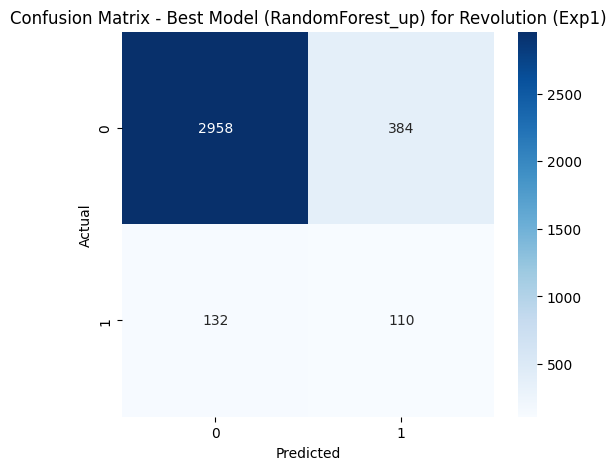


  --- ROC-AUC кривая для лучшей модели (RandomForest_up) ---


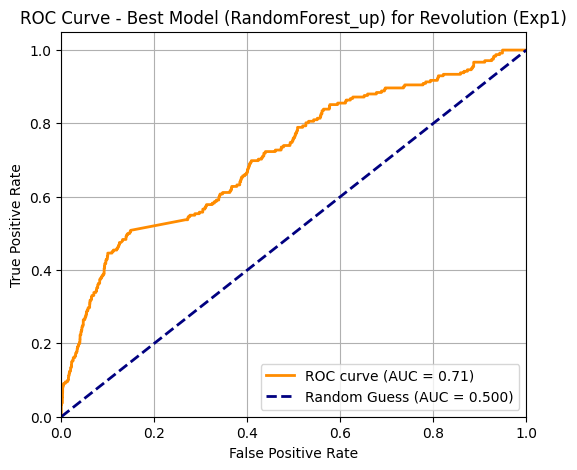


  --- Важность признаков для лучшей модели (RandomForest_up) ---


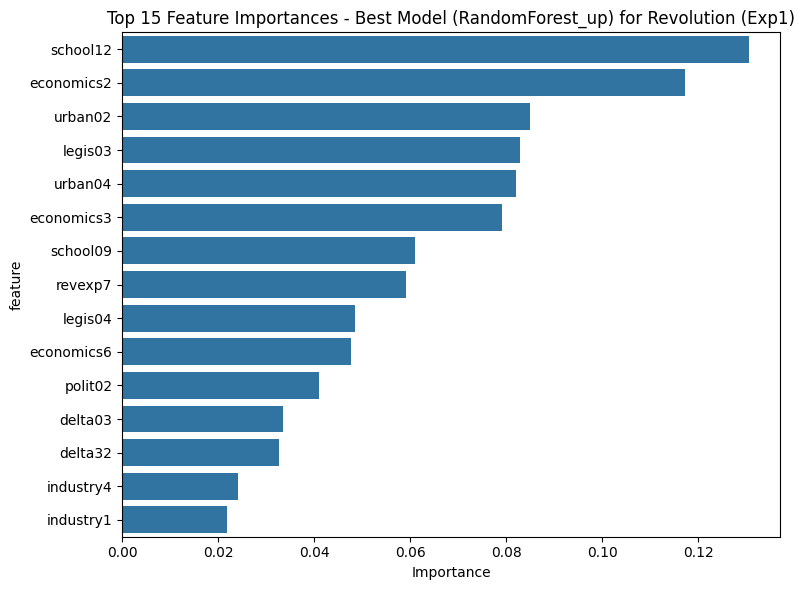

  График важности признаков показан.
   feature  importance
  school12      0.1305
economics2      0.1173
   urban02      0.0850
   legis03      0.0828
   urban04      0.0821
economics3      0.0792
  school09      0.0611
   revexp7      0.0590
   legis04      0.0484
economics6      0.0476
   polit02      0.0409
   delta03      0.0336
   delta32      0.0328
 industry4      0.0241
 industry1      0.0219

--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей ---


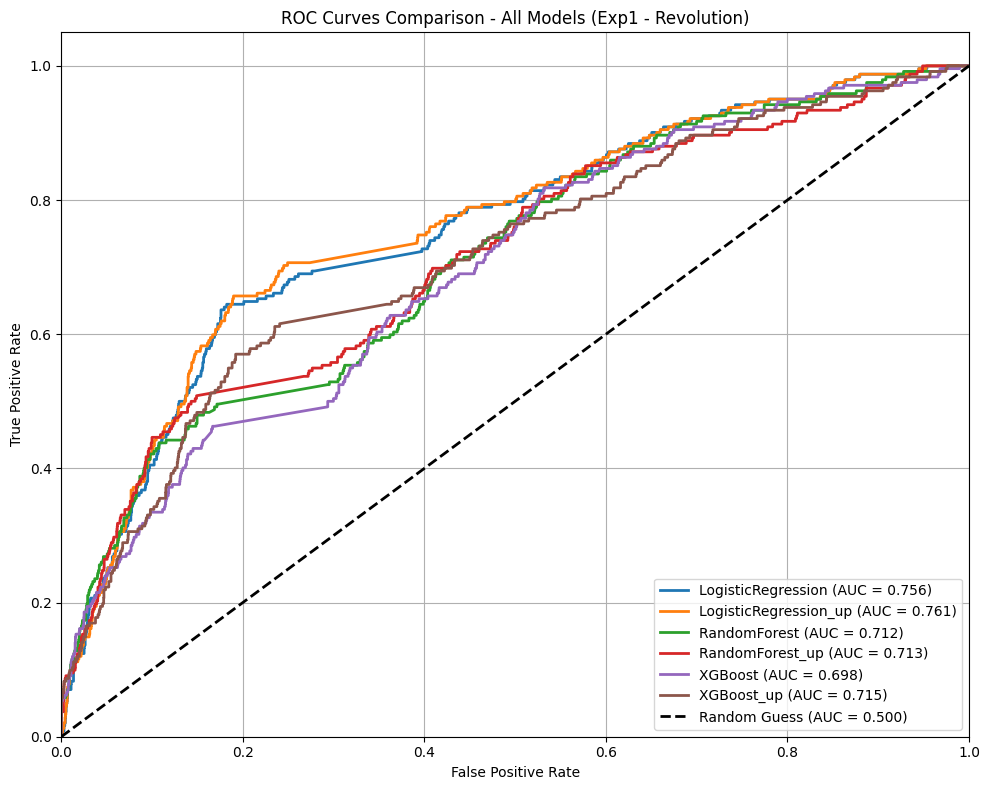

  Сводный график ROC-AUC для всех моделей показан.

--- Эксперимент 1 завершен ---


In [ ]:
! pip install optuna
# --- Блок 2: Эксперимент 1 - Нулевое и Первое поколения ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Модели: LR, RF, XGB (базовые и с подобранными гиперпараметрами через Optuna) ---
print("\n" + "="*60)
print("--- Эксперимент 1: Нулевое и Первое поколения ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Определение признаков (Эксперимент 1 - Марксистский акцент) ---
print("--- Шаг 1: Определение признаков Эксперимента 1 ---")
features_exp1 = [
    # Экономическое развитие/неравенство
    'economics2', 'economics3', 'economics4', 'economics6', 'economics7', 'delta32',
    # Структура производства
    'industry1', 'industry3', 'industry4',
    # Урбанизация
    'urban02', 'urban04', 'delta03',
    # Образование
    'school12', 'school09',
    # Политическая система (косвенно)
    'polit02', 'legis03', 'legis04',
    # Государственные расходы
    'revexp7',
]

# Проверка наличия признаков
available_features_exp1 = [f for f in features_exp1 if f in X_train_full.columns]
missing_features_exp1 = [f for f in features_exp1 if f not in X_train_full.columns]
if missing_features_exp1:
    print(f"Предупреждение: Следующие признаки отсутствуют: {missing_features_exp1}")
print(f"Используемые признаки ({len(available_features_exp1)}): {available_features_exp1}")

# --- 2. Подготовка данных для Эксперимента 1 ---
print("\n--- Шаг 2: Подготовка данных для Эксперимента 1 ---")
X_train_exp1 = X_train_full[available_features_exp1]
X_test_exp1 = X_test_full[available_features_exp1]

# Заполнение пропусков
X_train_exp1 = X_train_exp1.fillna(X_train_exp1.median(numeric_only=True))
X_test_exp1 = X_test_exp1.fillna(X_test_exp1.median(numeric_only=True))

print(f"Размер обучающей выборки для Exp1: {X_train_exp1.shape}")
print(f"Размер тестовой выборки для Exp1: {X_test_exp1.shape}")

# --- 3. Определение функций для оптимизации с Optuna ---
print("\n--- Шаг 3: Определение функций оптимизации Optuna ---")

# --- a) Objective для Logistic Regression ---
def objective_lr(trial):
    """Целевая функция для оптимизации LogisticRegression."""
    params = {
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'C': trial.suggest_float('C', 0.001, 100.0, log=True),
        'solver': 'liblinear', # Фиксированный солвер
        'max_iter': 1000,
        'random_state': 42
    }
    model = LogisticRegression(**params)
    model.fit(X_train_exp1, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp1)[:, 1]
    try:
        # Используем F1-Score для класса 1 как метрику для оптимизации
        y_pred = model.predict(X_test_exp1)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для Random Forest ---
def objective_rf(trial):
    """Целевая функция для оптимизации RandomForestClassifier."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_exp1, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp1)[:, 1]
    try:
        y_pred = model.predict(X_test_exp1)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- c) Objective для XGBoost ---
def objective_xgb(trial):
    """Целевая функция для оптимизации XGBClassifier."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_exp1, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp1)[:, 1]
    try:
        y_pred = model.predict(X_test_exp1)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 4. Запуск оптимизации с Optuna ---
print("\n--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store = {} # Для хранения лучших параметров

# --- a) Оптимизация Logistic Regression ---
print("  Оптимизация Logistic Regression...")
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=False)
best_params_lr = study_lr.best_params
best_params_store['LogisticRegression_up'] = best_params_lr
print(f"    Лучшие параметры LR: {best_params_lr}")
print(f"    Лучший F1-Score (Class 1) (LR): {study_lr.best_value:.4f}")

# --- b) Оптимизация Random Forest ---
print("  Оптимизация Random Forest...")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=False)
best_params_rf = study_rf.best_params
best_params_store['RandomForest_up'] = best_params_rf
print(f"    Лучшие параметры RF: {best_params_rf}")
print(f"    Лучший F1-Score (Class 1) (RF): {study_rf.best_value:.4f}")

# --- c) Оптимизация XGBoost ---
print("  Оптимизация XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=False)
best_params_xgb = study_xgb.best_params
best_params_store['XGBoost_up'] = best_params_xgb
print(f"    Лучшие параметры XGB: {best_params_xgb}")
print(f"    Лучший F1-Score (Class 1) (XGB): {study_xgb.best_value:.4f}")

# --- 5. Обучение и оценка 6 моделей ---
print("\n--- Шаг 5: Обучение и оценка 6 моделей ---")
model_predictions_exp1 = {} # Для хранения прогнозов и моделей

# --- Модель 1a: Логистическая регрессия (базовая) ---
print("  Обучение Logistic Regression (базовая)...")
model_lr_exp1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, random_state=42)
model_lr_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_lr = model_lr_exp1.predict(X_test_exp1)
y_pred_proba_rev_lr = model_lr_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "LogisticRegression", "Revolution", y_test_rev, y_pred_rev_lr, y_pred_proba_rev_lr)
model_predictions_exp1['LogisticRegression'] = (y_pred_rev_lr, y_pred_proba_rev_lr, model_lr_exp1)

# --- Модель 1b: Логистическая регрессия (улучшенная) ---
print("  Обучение Logistic Regression (улучшенная)...")
best_params_lr_full = {**best_params_lr, 'solver': 'liblinear', 'max_iter': 1000, 'random_state': 42}
model_lr_up_exp1 = LogisticRegression(**best_params_lr_full)
model_lr_up_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_lr_up = model_lr_up_exp1.predict(X_test_exp1)
y_pred_proba_rev_lr_up = model_lr_up_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "LogisticRegression_up", "Revolution", y_test_rev, y_pred_rev_lr_up, y_pred_proba_rev_lr_up)
model_predictions_exp1['LogisticRegression_up'] = (y_pred_rev_lr_up, y_pred_proba_rev_lr_up, model_lr_up_exp1)

# --- Модель 1c: Random Forest (базовая) ---
print("  Обучение Random Forest (базовая)...")
model_rf_exp1 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
model_rf_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_rf = model_rf_exp1.predict(X_test_exp1)
y_pred_proba_rev_rf = model_rf_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf, y_pred_proba_rev_rf)
model_predictions_exp1['RandomForest'] = (y_pred_rev_rf, y_pred_proba_rev_rf, model_rf_exp1)

# --- Модель 1d: Random Forest (улучшенная) ---
print("  Обучение Random Forest (улучшенная)...")
best_params_rf_full = {**best_params_rf, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
model_rf_up_exp1 = RandomForestClassifier(**best_params_rf_full)
model_rf_up_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_rf_up = model_rf_up_exp1.predict(X_test_exp1)
y_pred_proba_rev_rf_up = model_rf_up_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up, y_pred_proba_rev_rf_up)
model_predictions_exp1['RandomForest_up'] = (y_pred_rev_rf_up, y_pred_proba_rev_rf_up, model_rf_up_exp1)

# --- Модель 1e: XGBoost (базовая) ---
print("  Обучение XGBoost (базовая)...")
model_xgb_exp1 = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
model_xgb_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_xgb = model_xgb_exp1.predict(X_test_exp1)
y_pred_proba_rev_xgb = model_xgb_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb, y_pred_proba_rev_xgb)
model_predictions_exp1['XGBoost'] = (y_pred_rev_xgb, y_pred_proba_rev_xgb, model_xgb_exp1)

# --- Модель 1f: XGBoost (улучшенная) ---
print("  Обучение XGBoost (улучшенная)...")
best_params_xgb_full = {**best_params_xgb, 'random_state': 42, 'n_jobs': -1}
model_xgb_up_exp1 = xgb.XGBClassifier(**best_params_xgb_full)
model_xgb_up_exp1.fit(X_train_exp1, y_train_rev)
y_pred_rev_xgb_up = model_xgb_up_exp1.predict(X_test_exp1)
y_pred_proba_rev_xgb_up = model_xgb_up_exp1.predict_proba(X_test_exp1)[:, 1]
save_results("Exp1", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up)
model_predictions_exp1['XGBoost_up'] = (y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up, model_xgb_up_exp1)

# --- 6. Сводка результатов Эксперимента 1 для Revolution ---
print("\n--- Шаг 6: Сводка результатов Эксперимента 1 (Revolution) ---")
# Фильтрация результатов только для текущего эксперимента и цели
exp1_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp1' and r['Target'] == 'Revolution']

if not exp1_rev_results:
    print("Нет результатов для отображения по Эксперименту 1 (Revolution).")
else:
    df_exp1_rev_summary = pd.DataFrame(exp1_rev_results)
    # Сортировка по F1-Score (Class 1) для удобства
    df_exp1_rev_summary = df_exp1_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp1), отсортированные по F1-Score (Class 1):")
    print(df_exp1_rev_summary.round(4).to_string(index=False))

# --- 7. Определение и анализ лучшей модели ---
print("\n--- Шаг 7: Анализ лучшей модели по F1-Score (Class 1) ---")
if exp1_rev_results:
    # Находим модель с наивысшим F1-Score (Class 1)
    best_model_entry = df_exp1_rev_summary.iloc[0]
    best_model_name = best_model_entry['Model']
    best_f1_class1 = best_model_entry['F1-Score (Class 1)']
    best_auc = best_model_entry['AUC-ROC']
    best_acc = best_model_entry['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1): {best_model_name}")
    print(f"    F1-Score (Class 1): {best_f1_class1:.4f}")
    print(f"    AUC-ROC: {best_auc:.4f}")
    print(f"    Accuracy: {best_acc:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best, y_pred_proba_best, model_best = model_predictions_exp1[best_model_name]

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name}) ---")
    try:
        report_best = classification_report(y_test_rev, y_pred_best, output_dict=True)
        df_report_best = pd.DataFrame(report_best).transpose()
        print(df_report_best.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name}) ---")
    try:
        cm_best = confusion_matrix(y_test_rev, y_pred_best)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name}) for Revolution (Exp1)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name}) ---")
    try:
        fpr_best, tpr_best, _ = roc_curve(y_test_rev, y_pred_proba_best)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name}) for Revolution (Exp1)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name}) ---")
    try:
        if hasattr(model_best, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance = model_best.feature_importances_
            features_df = pd.DataFrame({'feature': available_features_exp1, 'importance': feature_importance})
            features_df = features_df.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name}) for Revolution (Exp1)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df.round(4).to_string(index=False))

        elif hasattr(model_best, 'coef_'):
            # Для линейных моделей (LogisticRegression)
            coef_importance = np.abs(model_best.coef_[0]) # Берем абсолютные значения коэффициентов
            features_df = pd.DataFrame({'feature': available_features_exp1, 'importance': coef_importance})
            features_df = features_df.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name}) for Revolution (Exp1)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 8. Сводный ROC-AUC график для всех 6 моделей ---
print("\n--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors # Используем палитру из 10 цветов
    model_color_map = dict(zip(model_predictions_exp1.keys(), colors[:len(model_predictions_exp1)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp1.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp1 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 1 завершен ---")



--- Эксперимент 2: Второе поколение теорий революций ---
--- Шаг 1: Определение признаков Эксперимента 2 ---
Используемые признаки (28): ['industry3', 'industry4', 'industry5', 'delta26', 'delta27', 'military1', 'military2', 'military3', 'military4', 'revexp7', 'industry1', 'industry2', 'delta24', 'delta25', 'legis02', 'legis01', 'legis07', 'polit01', 'delta32', 'delta05', 'delta06', 'urban02', 'urban04', 'delta03', 'school09', 'school12', 'economics6', 'economics7']

--- Шаг 2: Подготовка данных для Эксперимента 2 ---
Размер обучающей выборки для Exp2: (14332, 28)
Размер тестовой выборки для Exp2: (3584, 28)

--- Шаг 3: Определение функций оптимизации Optuna ---

--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---
  Оптимизация Logistic Regression (Exp2)...
    Лучшие параметры LR (Exp2): {'penalty': 'l1', 'C': 0.856080407025451}
    Лучший F1-Score (Class 1) (LR): 0.0341
  Оптимизация Random Forest (Exp2)...
    Лучшие параметры RF (Exp2): {'n_estimators': 295, 'max_de

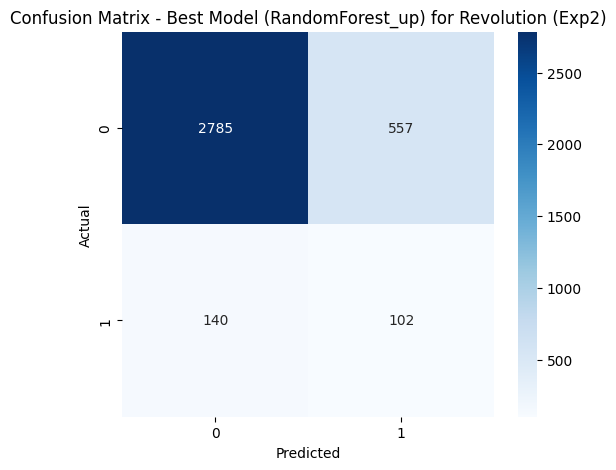


  --- ROC-AUC кривая для лучшей модели (RandomForest_up) ---


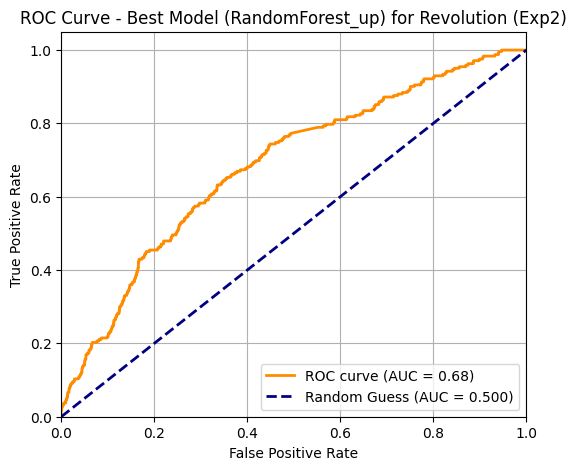


  --- Важность признаков для лучшей модели (RandomForest_up) ---


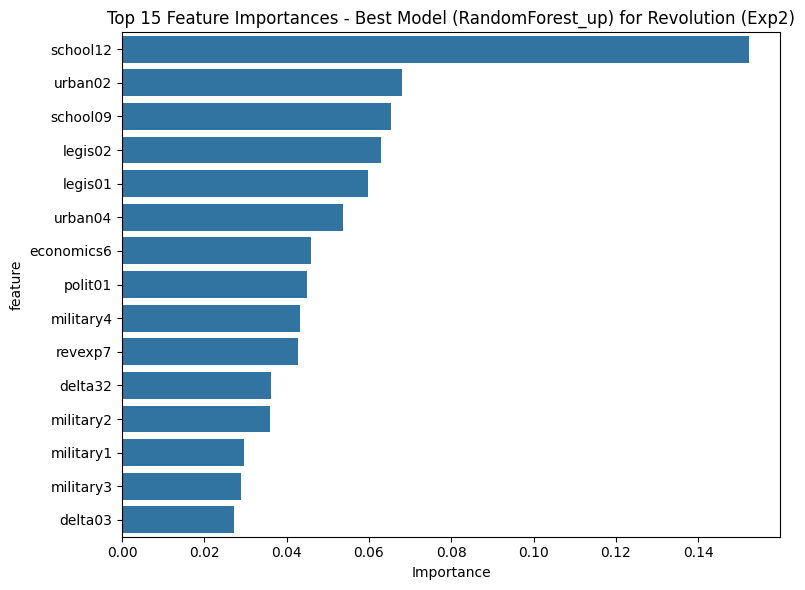

  График важности признаков показан.
   feature  importance
  school12      0.1523
   urban02      0.0680
  school09      0.0653
   legis02      0.0630
   legis01      0.0597
   urban04      0.0536
economics6      0.0460
   polit01      0.0450
 military4      0.0433
   revexp7      0.0428
   delta32      0.0363
 military2      0.0359
 military1      0.0297
 military3      0.0290
   delta03      0.0273

--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей (Exp2) ---


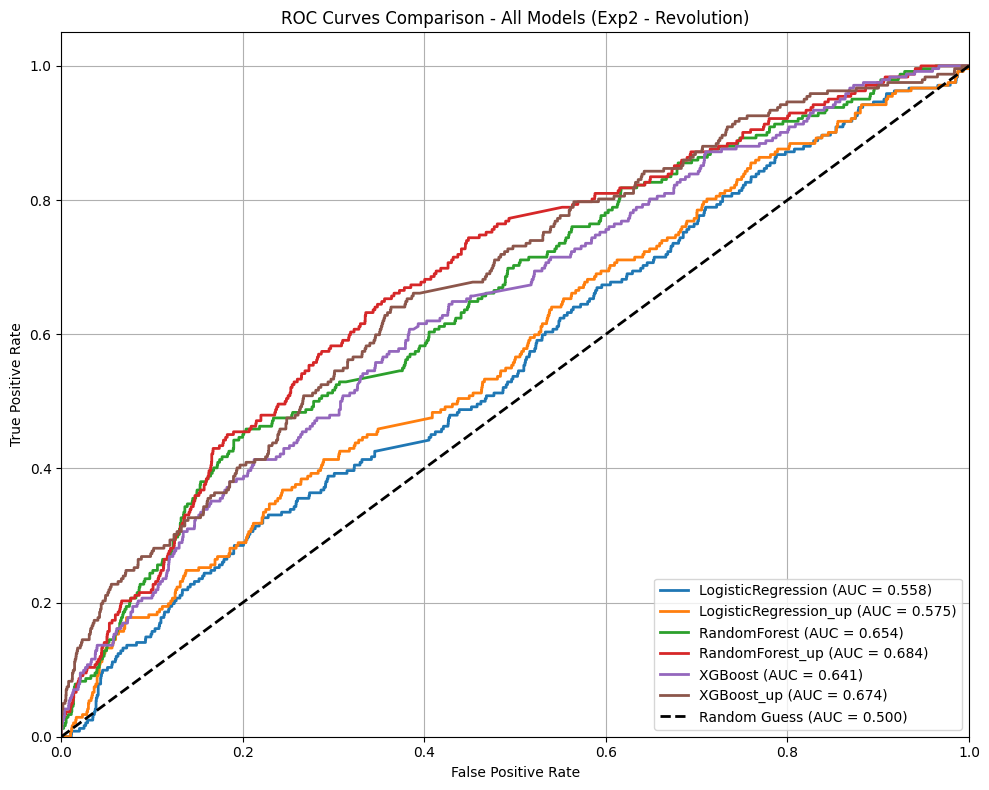

  Сводный график ROC-AUC для всех моделей Exp2 показан.

--- Эксперимент 2 завершен ---


In [ ]:
# --- Блок 3: Эксперимент 2 - Второе поколение теорий революций ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Теория: Структурные факторы, модернизация, фрустрация (J-кривая) ---
# --- Модели: LR, RF, XGB (базовые и с подобранными гиперпараметрами через Optuna) ---
print("\n" + "="*60)
print("--- Эксперимент 2: Второе поколение теорий революций ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Определение признаков (Эксперимент 2 - Второе поколение: структура, модернизация) ---
print("--- Шаг 1: Определение признаков Эксперимента 2 ---")
# Признаки согласно теории второго поколения (структурные и модернизационные):
# Аграрная структура, военная мощь, индустриализация, урбанизация, образование, неравенство
features_exp2 = [
    # Аграрная структура
    'industry3', # Percent Work Force in Agriculture (Scaling: 0.1)
    'industry4', # Percent Work in Industry (Scaling: 0.1)
    'industry5', # Percent Work Force in Other Activity (Scaling: 0.1)
    'delta26',   # % Annual Increase: Percent Work Force in Agriculture (Scaling: 0.01)
    'delta27',   # % Annual Increase: Percent Work Force in Industry (Scaling: 0.01)

    # Военная структура
    'military1', # National Defense Expenditure (Scaling: 10000)
    'military2', # National Defense Expenditure Per Capita (Scaling: 0.01)
    'military3', # Size of Military (Scaling: 1000)
    'military4', # Size of Military/Population (Scaling: 0.0001)
    'revexp7',   # Nat'l Defense Expenditure/Nat'l Gov't Expenditure (Scaling: 0.001)

    # Индустриализация и модернизация
    'industry1', # Percent GDP Originating in Industrial Activity
    'industry2', # Per Capita GDP Originating in Industrial Activity
    'delta24',   # % Annual Increase: Percent GDP Originating in Industrial Activity (Scaling: 0.01)
    'delta25',   # % Annual Increase: Per Capita GDP Originating in Industrial Activity (Scaling: 0.01)

    # Социальная/политическая структура
    'legis02',   # Size of Legislature (Lower House)
    'legis01',   # Number of Seats Largest Party in Legislature
    'legis07',   # Size of Legislature/Number of Seats Largest Party (Scaling: 0.01)
    'polit01',   # Party Fractionalization Index (Scaling: 0.0001)

    # Экономический кризис (косвенно)
    'delta32',   # % Annual Increase: Gross Domestic Product Per Capita (Scaling: 0.01)
    'delta05',   # % Annual Increase: National Government Revenue Per Capita (Scaling: 0.01)
    'delta06',   # % Annual Increase: National Government Expenditure Per Capita (Scaling: 0.01)

    # Урбанизация (уже частично включена, но добавим явно)
    'urban02',   # Population Cities of 100000 & Over Per Capita (Scaling: 0.001)
    'urban04',   # Population Cities of 50000 & Over Per Capita (Scaling: 0.001)
    'delta03',   # % Annual Increase: Population Cities of 100000 & Over Per Capita (Scaling: 0.01)

    # Образование (уже частично включено)
    'school09',  # University Enrollment Per Capita (Scaling: 0.0001)
    'school12',  # Percent Literate (Scaling: 0.1)

    # Индикаторы неравенства (косвенно)
    'economics6', # Official/Princial Exchange Rate Local Currency/$US (Scaling: 0.01)
    'economics7', # Free/Black Market Rate Local Currency Per $US (Scaling: 0.01)
]

# Проверка наличия признаков
available_features_exp2 = [f for f in features_exp2 if f in X_train_full.columns]
missing_features_exp2 = [f for f in features_exp2 if f not in X_train_full.columns]
if missing_features_exp2:
    print(f"Предупреждение: Следующие признаки отсутствуют: {missing_features_exp2}")
print(f"Используемые признаки ({len(available_features_exp2)}): {available_features_exp2}")

# --- 2. Подготовка данных для Эксперимента 2 ---
print("\n--- Шаг 2: Подготовка данных для Эксперимента 2 ---")
X_train_exp2 = X_train_full[available_features_exp2]
X_test_exp2 = X_test_full[available_features_exp2]

# Заполнение пропусков
X_train_exp2 = X_train_exp2.fillna(X_train_exp2.median(numeric_only=True))
X_test_exp2 = X_test_exp2.fillna(X_test_exp2.median(numeric_only=True))

print(f"Размер обучающей выборки для Exp2: {X_train_exp2.shape}")
print(f"Размер тестовой выборки для Exp2: {X_test_exp2.shape}")

# --- 3. Определение функций для оптимизации с Optuna ---
print("\n--- Шаг 3: Определение функций оптимизации Optuna ---")

# --- a) Objective для Logistic Regression ---
def objective_lr_exp2(trial):
    """Целевая функция для оптимизации LogisticRegression (Exp2)."""
    params = {
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'C': trial.suggest_float('C', 0.001, 100.0, log=True),
        'solver': 'liblinear', # Фиксированный солвер
        'max_iter': 1000,
        'random_state': 42
    }
    model = LogisticRegression(**params)
    model.fit(X_train_exp2, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp2)[:, 1]
    try:
        y_pred = model.predict(X_test_exp2)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для Random Forest ---
def objective_rf_exp2(trial):
    """Целевая функция для оптимизации RandomForestClassifier (Exp2)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_exp2, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp2)[:, 1]
    try:
        y_pred = model.predict(X_test_exp2)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- c) Objective для XGBoost ---
def objective_xgb_exp2(trial):
    """Целевая функция для оптимизации XGBClassifier (Exp2)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_exp2, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp2)[:, 1]
    try:
        y_pred = model.predict(X_test_exp2)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 4. Запуск оптимизации с Optuna ---
print("\n--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store_exp2 = {} # Для хранения лучших параметров

# --- a) Оптимизация Logistic Regression ---
print("  Оптимизация Logistic Regression (Exp2)...")
study_lr_exp2 = optuna.create_study(direction='maximize')
study_lr_exp2.optimize(objective_lr_exp2, n_trials=30, show_progress_bar=False)
best_params_lr_exp2 = study_lr_exp2.best_params
best_params_store_exp2['LogisticRegression_up'] = best_params_lr_exp2
print(f"    Лучшие параметры LR (Exp2): {best_params_lr_exp2}")
print(f"    Лучший F1-Score (Class 1) (LR): {study_lr_exp2.best_value:.4f}")

# --- b) Оптимизация Random Forest ---
print("  Оптимизация Random Forest (Exp2)...")
study_rf_exp2 = optuna.create_study(direction='maximize')
study_rf_exp2.optimize(objective_rf_exp2, n_trials=30, show_progress_bar=False)
best_params_rf_exp2 = study_rf_exp2.best_params
best_params_store_exp2['RandomForest_up'] = best_params_rf_exp2
print(f"    Лучшие параметры RF (Exp2): {best_params_rf_exp2}")
print(f"    Лучший F1-Score (Class 1) (RF): {study_rf_exp2.best_value:.4f}")

# --- c) Оптимизация XGBoost ---
print("  Оптимизация XGBoost (Exp2)...")
study_xgb_exp2 = optuna.create_study(direction='maximize')
study_xgb_exp2.optimize(objective_xgb_exp2, n_trials=30, show_progress_bar=False)
best_params_xgb_exp2 = study_xgb_exp2.best_params
best_params_store_exp2['XGBoost_up'] = best_params_xgb_exp2
print(f"    Лучшие параметры XGB (Exp2): {best_params_xgb_exp2}")
print(f"    Лучший F1-Score (Class 1) (XGB): {study_xgb_exp2.best_value:.4f}")

# --- 5. Обучение и оценка 6 моделей ---
print("\n--- Шаг 5: Обучение и оценка 6 моделей (Exp2) ---")
model_predictions_exp2 = {} # Для хранения прогнозов и моделей

# --- Модель 2a: Логистическая регрессия (базовая) ---
print("  Обучение Logistic Regression (базовая, Exp2)...")
model_lr_exp2 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, random_state=42)
model_lr_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_lr_exp2 = model_lr_exp2.predict(X_test_exp2)
y_pred_proba_rev_lr_exp2 = model_lr_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "LogisticRegression", "Revolution", y_test_rev, y_pred_rev_lr_exp2, y_pred_proba_rev_lr_exp2)
model_predictions_exp2['LogisticRegression'] = (y_pred_rev_lr_exp2, y_pred_proba_rev_lr_exp2, model_lr_exp2)

# --- Модель 2b: Логистическая регрессия (улучшенная) ---
print("  Обучение Logistic Regression (улучшенная, Exp2)...")
best_params_lr_full_exp2 = {**best_params_lr_exp2, 'solver': 'liblinear', 'max_iter': 1000, 'random_state': 42}
model_lr_up_exp2 = LogisticRegression(**best_params_lr_full_exp2)
model_lr_up_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_lr_up_exp2 = model_lr_up_exp2.predict(X_test_exp2)
y_pred_proba_rev_lr_up_exp2 = model_lr_up_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "LogisticRegression_up", "Revolution", y_test_rev, y_pred_rev_lr_up_exp2, y_pred_proba_rev_lr_up_exp2)
model_predictions_exp2['LogisticRegression_up'] = (y_pred_rev_lr_up_exp2, y_pred_proba_rev_lr_up_exp2, model_lr_up_exp2)

# --- Модель 2c: Random Forest (базовая) ---
print("  Обучение Random Forest (базовая, Exp2)...")
model_rf_exp2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
model_rf_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_rf_exp2 = model_rf_exp2.predict(X_test_exp2)
y_pred_proba_rev_rf_exp2 = model_rf_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf_exp2, y_pred_proba_rev_rf_exp2)
model_predictions_exp2['RandomForest'] = (y_pred_rev_rf_exp2, y_pred_proba_rev_rf_exp2, model_rf_exp2)

# --- Модель 2d: Random Forest (улучшенная) ---
print("  Обучение Random Forest (улучшенная, Exp2)...")
best_params_rf_full_exp2 = {**best_params_rf_exp2, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
model_rf_up_exp2 = RandomForestClassifier(**best_params_rf_full_exp2)
model_rf_up_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_rf_up_exp2 = model_rf_up_exp2.predict(X_test_exp2)
y_pred_proba_rev_rf_up_exp2 = model_rf_up_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up_exp2, y_pred_proba_rev_rf_up_exp2)
model_predictions_exp2['RandomForest_up'] = (y_pred_rev_rf_up_exp2, y_pred_proba_rev_rf_up_exp2, model_rf_up_exp2)

# --- Модель 2e: XGBoost (базовая) ---
print("  Обучение XGBoost (базовая, Exp2)...")
model_xgb_exp2 = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
model_xgb_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_xgb_exp2 = model_xgb_exp2.predict(X_test_exp2)
y_pred_proba_rev_xgb_exp2 = model_xgb_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb_exp2, y_pred_proba_rev_xgb_exp2)
model_predictions_exp2['XGBoost'] = (y_pred_rev_xgb_exp2, y_pred_proba_rev_xgb_exp2, model_xgb_exp2)

# --- Модель 2f: XGBoost (улучшенная) ---
print("  Обучение XGBoost (улучшенная, Exp2)...")
best_params_xgb_full_exp2 = {**best_params_xgb_exp2, 'random_state': 42, 'n_jobs': -1}
model_xgb_up_exp2 = xgb.XGBClassifier(**best_params_xgb_full_exp2)
model_xgb_up_exp2.fit(X_train_exp2, y_train_rev)
y_pred_rev_xgb_up_exp2 = model_xgb_up_exp2.predict(X_test_exp2)
y_pred_proba_rev_xgb_up_exp2 = model_xgb_up_exp2.predict_proba(X_test_exp2)[:, 1]
save_results("Exp2", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up_exp2, y_pred_proba_rev_xgb_up_exp2)
model_predictions_exp2['XGBoost_up'] = (y_pred_rev_xgb_up_exp2, y_pred_proba_rev_xgb_up_exp2, model_xgb_up_exp2)

# --- 6. Сводка результатов Эксперимента 2 для Revolution ---
print("\n--- Шаг 6: Сводка результатов Эксперимента 2 (Revolution) ---")
# Фильтрация результатов только для текущего эксперимента и цели
exp2_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp2' and r['Target'] == 'Revolution']

if not exp2_rev_results:
    print("Нет результатов для отображения по Эксперименту 2 (Revolution).")
else:
    df_exp2_rev_summary = pd.DataFrame(exp2_rev_results)
    # Сортировка по F1-Score (Class 1) для удобства
    df_exp2_rev_summary = df_exp2_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp2), отсортированные по F1-Score (Class 1):")
    print(df_exp2_rev_summary.round(4).to_string(index=False))

# --- 7. Определение и анализ лучшей модели ---
print("\n--- Шаг 7: Анализ лучшей модели по F1-Score (Class 1) (Exp2) ---")
if exp2_rev_results:
    # Находим модель с наивысшим F1-Score (Class 1)
    best_model_entry_exp2 = df_exp2_rev_summary.iloc[0] # Первая строка после сортировки
    best_model_name_exp2 = best_model_entry_exp2['Model']
    best_f1_class1_exp2 = best_model_entry_exp2['F1-Score (Class 1)']
    best_auc_exp2 = best_model_entry_exp2['AUC-ROC']
    best_acc_exp2 = best_model_entry_exp2['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1) (Exp2): {best_model_name_exp2}")
    print(f"    F1-Score (Class 1): {best_f1_class1_exp2:.4f}")
    print(f"    AUC-ROC: {best_auc_exp2:.4f}")
    print(f"    Accuracy: {best_acc_exp2:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best_exp2, y_pred_proba_best_exp2, model_best_exp2 = model_predictions_exp2[best_model_name_exp2]

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name_exp2}) ---")
    try:
        report_best_exp2 = classification_report(y_test_rev, y_pred_best_exp2, output_dict=True)
        df_report_best_exp2 = pd.DataFrame(report_best_exp2).transpose()
        print(df_report_best_exp2.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name_exp2}) ---")
    try:
        cm_best_exp2 = confusion_matrix(y_test_rev, y_pred_best_exp2)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best_exp2, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name_exp2}) for Revolution (Exp2)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name_exp2}) ---")
    try:
        fpr_best_exp2, tpr_best_exp2, _ = roc_curve(y_test_rev, y_pred_proba_best_exp2)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best_exp2, tpr_best_exp2, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc_exp2:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name_exp2}) for Revolution (Exp2)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name_exp2}) ---")
    try:
        if hasattr(model_best_exp2, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance_exp2 = model_best_exp2.feature_importances_
            features_df_exp2 = pd.DataFrame({'feature': available_features_exp2, 'importance': feature_importance_exp2})
            features_df_exp2 = features_df_exp2.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp2)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name_exp2}) for Revolution (Exp2)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df_exp2.round(4).to_string(index=False))

        elif hasattr(model_best_exp2, 'coef_'):
            # Для линейных моделей (LogisticRegression)
            coef_importance_exp2 = np.abs(model_best_exp2.coef_[0]) # Абсолютные значения коэффициентов
            features_df_exp2 = pd.DataFrame({'feature': available_features_exp2, 'importance': coef_importance_exp2})
            features_df_exp2 = features_df_exp2.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp2)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name_exp2}) for Revolution (Exp2)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df_exp2.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 8. Сводный ROC-AUC график для всех 6 моделей ---
print("\n--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей (Exp2) ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors
    model_color_map = dict(zip(model_predictions_exp2.keys(), colors[:len(model_predictions_exp2)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp2.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp2 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей Exp2 показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 2 завершен ---")



--- Эксперимент 3: Третье поколение теорий революций ---
--- Шаг 1: Определение признаков Эксперимента 3 ---
Используемые признаки (23): ['revexp3', 'revexp4', 'revexp5', 'revexp6', 'delta05', 'delta06', 'revexp7', 'instat1', 'instat3', 'instat5', 'legis02', 'legis03', 'legis04', 'legis07', 'trade2', 'trade4', 'military1', 'military2', 'military4', 'economics2', 'delta32', 'school12', 'urban02']

--- Шаг 2: Подготовка данных для Эксперимента 3 ---
Размер обучающей выборки для Exp3: (14332, 23)
Размер тестовой выборки для Exp3: (3584, 23)

--- Шаг 3: Определение функций оптимизации Optuna ---

--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---
  Оптимизация Logistic Regression (Exp3)...
    Лучшие параметры LR (Exp3): {'penalty': 'l2', 'C': 37.80518887194791}
    Лучший F1-Score (Class 1) (LR): 0.0649
  Оптимизация Random Forest (Exp3)...
    Лучшие параметры RF (Exp3): {'n_estimators': 262, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 10}
    Лучший F1-Sc

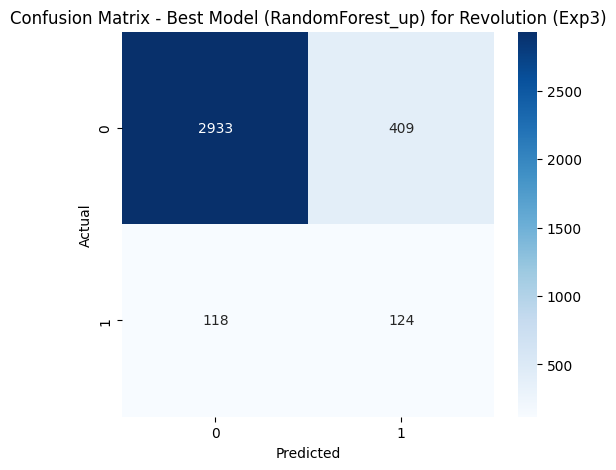


  --- ROC-AUC кривая для лучшей модели (RandomForest_up) ---


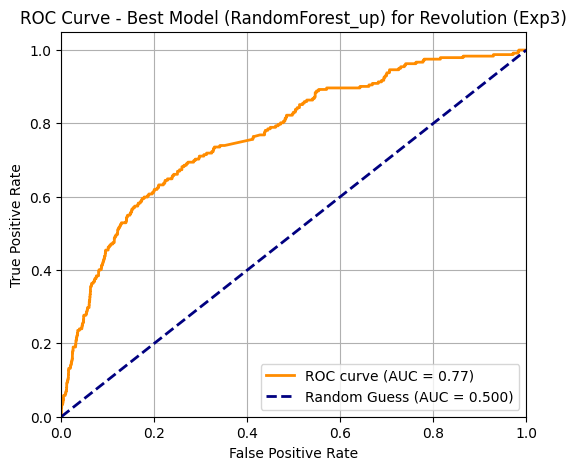


  --- Важность признаков для лучшей модели (RandomForest_up) ---


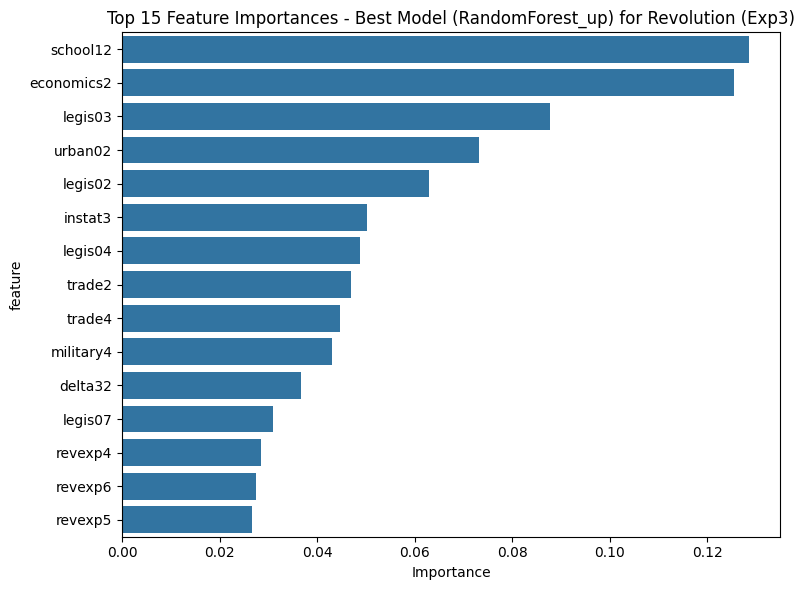

  График важности признаков показан.
   feature  importance
  school12      0.1285
economics2      0.1256
   legis03      0.0877
   urban02      0.0731
   legis02      0.0630
   instat3      0.0502
   legis04      0.0488
    trade2      0.0470
    trade4      0.0448
 military4      0.0430
   delta32      0.0368
   legis07      0.0309
   revexp4      0.0284
   revexp6      0.0275
   revexp5      0.0266

--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей (Exp3) ---


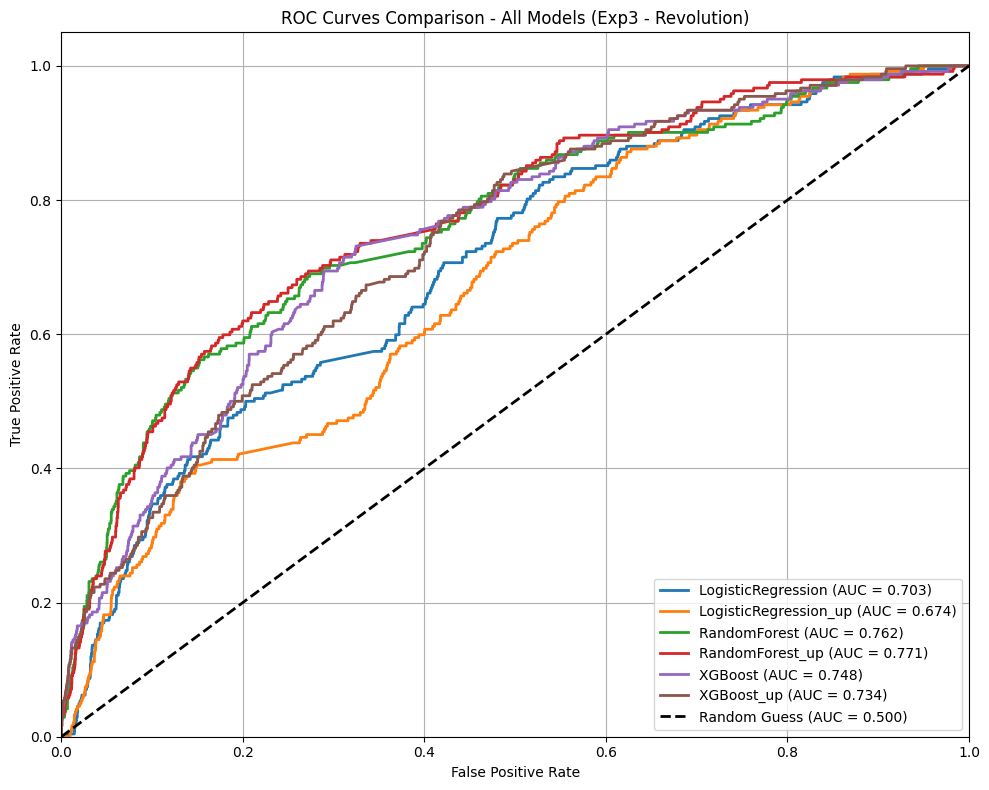

  Сводный график ROC-AUC для всех моделей Exp3 показан.

--- Эксперимент 3 завершен ---


In [ ]:
# --- Блок 4: Эксперимент 3 - Третье поколение теорий революций ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Теория: Институциональный и сравнительный подход (Skocpol, Tilly) ---
# --- Модели: LR, RF, XGB (базовые и с подобранными гиперпараметрами через Optuna) ---
print("\n" + "="*60)
print("--- Эксперимент 3: Третье поколение теорий революций ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Определение признаков (Эксперимент 3 - Третье поколение: институты, государство) ---
print("--- Шаг 1: Определение признаков Эксперимента 3 ---")
# Признаки согласно теории третьего поколения (институциональные и государственные):
# Фискальная устойчивость, государственная автономия, эффективность институтов, международное давление
features_exp3 = [
    # Фискальная устойчивость и эффективность
    'revexp3', # Nat'l Gov't Revenue (Scaling: 1000)
    'revexp4', # Nat'l Gov't Revenue Per Capita (Scaling: 0.01)
    'revexp5', # Nat'l Gov't Expenditure (Scaling: 1000)
    'revexp6', # Nat'l Gov't Expenditure Per Capita (Scaling: 0.01)
    'delta05', # % Annual Increase: National Government Revenue Per Capita (Scaling: 0.01)
    'delta06', # % Annual Increase: National Government Expenditure Per Capita (Scaling: 0.01)
    'revexp7', # Nat'l Defense Expenditure/Nat'l Gov't Expenditure (Scaling: 0.001)

    # Государственная автономия / Институты
    'instat1', # International Status Ranking
    'instat3', # International Status Composite Score
    'instat5', # International Status Quintile
    'legis02', # Size of Legislature (Lower House)
    'legis03', # Effectiveness of Legislature
    'legis04', # Competitiveness of Nominating Process
    'legis07', # Size of Legislature/Number of Seats Largest Party (Scaling: 0.01)

    # Международное давление / Торговля
    'trade2', # Imports Per Capita (Scaling: 0.01)
    'trade4', # Exports Per Capita (Scaling: 0.01)
    # trade5, # Proportion of World Trade (Scaling: 0.00001) - может быть полезно
    'military1', # National Defense Expenditure (Scaling: 10000)

    # Военные факторы
    'military2', # National Defense Expenditure Per Capita (Scaling: 0.01)
    'military4', # Size of Military/Population (Scaling: 0.0001)

    # Экономическая основа
    'economics2', # Gross Domestic Product Per Capita (Factor Cost)
    'delta32', # % Annual Increase: Gross Domestic Product Per Capita (Scaling: 0.01)

    # Социальная структура
    'school12', # Percent Literate (Scaling: 0.1)
    'urban02',  # Population Cities of 100000 & Over Per Capita (Scaling: 0.001)
]

# Проверка наличия признаков
available_features_exp3 = [f for f in features_exp3 if f in X_train_full.columns]
missing_features_exp3 = [f for f in features_exp3 if f not in X_train_full.columns]
if missing_features_exp3:
    print(f"Предупреждение: Следующие признаки отсутствуют: {missing_features_exp3}")
print(f"Используемые признаки ({len(available_features_exp3)}): {available_features_exp3}")

# --- 2. Подготовка данных для Эксперимента 3 ---
print("\n--- Шаг 2: Подготовка данных для Эксперимента 3 ---")
X_train_exp3 = X_train_full[available_features_exp3]
X_test_exp3 = X_test_full[available_features_exp3]

# Заполнение пропусков
X_train_exp3 = X_train_exp3.fillna(X_train_exp3.median(numeric_only=True))
X_test_exp3 = X_test_exp3.fillna(X_test_exp3.median(numeric_only=True))

print(f"Размер обучающей выборки для Exp3: {X_train_exp3.shape}")
print(f"Размер тестовой выборки для Exp3: {X_test_exp3.shape}")

# --- 3. Определение функций для оптимизации с Optuna ---
print("\n--- Шаг 3: Определение функций оптимизации Optuna ---")

# --- a) Objective для Logistic Regression ---
def objective_lr_exp3(trial):
    """Целевая функция для оптимизации LogisticRegression (Exp3)."""
    params = {
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'C': trial.suggest_float('C', 0.001, 100.0, log=True),
        'solver': 'liblinear', # Фиксированный солвер
        'max_iter': 1000,
        'random_state': 42
    }
    model = LogisticRegression(**params)
    model.fit(X_train_exp3, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp3)[:, 1]
    try:
        y_pred = model.predict(X_test_exp3)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для Random Forest ---
def objective_rf_exp3(trial):
    """Целевая функция для оптимизации RandomForestClassifier (Exp3)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_exp3, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp3)[:, 1]
    try:
        y_pred = model.predict(X_test_exp3)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- c) Objective для XGBoost ---
def objective_xgb_exp3(trial):
    """Целевая функция для оптимизации XGBClassifier (Exp3)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_exp3, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_exp3)[:, 1]
    try:
        y_pred = model.predict(X_test_exp3)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 4. Запуск оптимизации с Optuna ---
print("\n--- Шаг 4: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store_exp3 = {} # Для хранения лучших параметров

# --- a) Оптимизация Logistic Regression ---
print("  Оптимизация Logistic Regression (Exp3)...")
study_lr_exp3 = optuna.create_study(direction='maximize')
study_lr_exp3.optimize(objective_lr_exp3, n_trials=30, show_progress_bar=False)
best_params_lr_exp3 = study_lr_exp3.best_params
best_params_store_exp3['LogisticRegression_up'] = best_params_lr_exp3
print(f"    Лучшие параметры LR (Exp3): {best_params_lr_exp3}")
print(f"    Лучший F1-Score (Class 1) (LR): {study_lr_exp3.best_value:.4f}")

# --- b) Оптимизация Random Forest ---
print("  Оптимизация Random Forest (Exp3)...")
study_rf_exp3 = optuna.create_study(direction='maximize')
study_rf_exp3.optimize(objective_rf_exp3, n_trials=30, show_progress_bar=False)
best_params_rf_exp3 = study_rf_exp3.best_params
best_params_store_exp3['RandomForest_up'] = best_params_rf_exp3
print(f"    Лучшие параметры RF (Exp3): {best_params_rf_exp3}")
print(f"    Лучший F1-Score (Class 1) (RF): {study_rf_exp3.best_value:.4f}")

# --- c) Оптимизация XGBoost ---
print("  Оптимизация XGBoost (Exp3)...")
study_xgb_exp3 = optuna.create_study(direction='maximize')
study_xgb_exp3.optimize(objective_xgb_exp3, n_trials=30, show_progress_bar=False)
best_params_xgb_exp3 = study_xgb_exp3.best_params
best_params_store_exp3['XGBoost_up'] = best_params_xgb_exp3
print(f"    Лучшие параметры XGB (Exp3): {best_params_xgb_exp3}")
print(f"    Лучший F1-Score (Class 1) (XGB): {study_xgb_exp3.best_value:.4f}")

# --- 5. Обучение и оценка 6 моделей ---
print("\n--- Шаг 5: Обучение и оценка 6 моделей (Exp3) ---")
model_predictions_exp3 = {} # Для хранения прогнозов и моделей

# --- Модель 3a: Логистическая регрессия (базовая) ---
print("  Обучение Logistic Regression (базовая, Exp3)...")
model_lr_exp3 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, random_state=42)
model_lr_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_lr_exp3 = model_lr_exp3.predict(X_test_exp3)
y_pred_proba_rev_lr_exp3 = model_lr_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "LogisticRegression", "Revolution", y_test_rev, y_pred_rev_lr_exp3, y_pred_proba_rev_lr_exp3)
model_predictions_exp3['LogisticRegression'] = (y_pred_rev_lr_exp3, y_pred_proba_rev_lr_exp3, model_lr_exp3)

# --- Модель 3b: Логистическая регрессия (улучшенная) ---
print("  Обучение Logistic Regression (улучшенная, Exp3)...")
best_params_lr_full_exp3 = {**best_params_lr_exp3, 'solver': 'liblinear', 'max_iter': 1000, 'random_state': 42}
model_lr_up_exp3 = LogisticRegression(**best_params_lr_full_exp3)
model_lr_up_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_lr_up_exp3 = model_lr_up_exp3.predict(X_test_exp3)
y_pred_proba_rev_lr_up_exp3 = model_lr_up_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "LogisticRegression_up", "Revolution", y_test_rev, y_pred_rev_lr_up_exp3, y_pred_proba_rev_lr_up_exp3)
model_predictions_exp3['LogisticRegression_up'] = (y_pred_rev_lr_up_exp3, y_pred_proba_rev_lr_up_exp3, model_lr_up_exp3)

# --- Модель 3c: Random Forest (базовая) ---
print("  Обучение Random Forest (базовая, Exp3)...")
model_rf_exp3 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
model_rf_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_rf_exp3 = model_rf_exp3.predict(X_test_exp3)
y_pred_proba_rev_rf_exp3 = model_rf_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf_exp3, y_pred_proba_rev_rf_exp3)
model_predictions_exp3['RandomForest'] = (y_pred_rev_rf_exp3, y_pred_proba_rev_rf_exp3, model_rf_exp3)

# --- Модель 3d: Random Forest (улучшенная) ---
print("  Обучение Random Forest (улучшенная, Exp3)...")
best_params_rf_full_exp3 = {**best_params_rf_exp3, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
model_rf_up_exp3 = RandomForestClassifier(**best_params_rf_full_exp3)
model_rf_up_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_rf_up_exp3 = model_rf_up_exp3.predict(X_test_exp3)
y_pred_proba_rev_rf_up_exp3 = model_rf_up_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up_exp3, y_pred_proba_rev_rf_up_exp3)
model_predictions_exp3['RandomForest_up'] = (y_pred_rev_rf_up_exp3, y_pred_proba_rev_rf_up_exp3, model_rf_up_exp3)

# --- Модель 3e: XGBoost (базовая) ---
print("  Обучение XGBoost (базовая, Exp3)...")
model_xgb_exp3 = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
model_xgb_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_xgb_exp3 = model_xgb_exp3.predict(X_test_exp3)
y_pred_proba_rev_xgb_exp3 = model_xgb_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb_exp3, y_pred_proba_rev_xgb_exp3)
model_predictions_exp3['XGBoost'] = (y_pred_rev_xgb_exp3, y_pred_proba_rev_xgb_exp3, model_xgb_exp3)

# --- Модель 3f: XGBoost (улучшенная) ---
print("  Обучение XGBoost (улучшенная, Exp3)...")
best_params_xgb_full_exp3 = {**best_params_xgb_exp3, 'random_state': 42, 'n_jobs': -1}
model_xgb_up_exp3 = xgb.XGBClassifier(**best_params_xgb_full_exp3)
model_xgb_up_exp3.fit(X_train_exp3, y_train_rev)
y_pred_rev_xgb_up_exp3 = model_xgb_up_exp3.predict(X_test_exp3)
y_pred_proba_rev_xgb_up_exp3 = model_xgb_up_exp3.predict_proba(X_test_exp3)[:, 1]
save_results("Exp3", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up_exp3, y_pred_proba_rev_xgb_up_exp3)
model_predictions_exp3['XGBoost_up'] = (y_pred_rev_xgb_up_exp3, y_pred_proba_rev_xgb_up_exp3, model_xgb_up_exp3)

# --- 6. Сводка результатов Эксперимента 3 для Revolution ---
print("\n--- Шаг 6: Сводка результатов Эксперимента 3 (Revolution) ---")
# Фильтрация результатов только для текущего эксперимента и цели
exp3_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp3' and r['Target'] == 'Revolution']

if not exp3_rev_results:
    print("Нет результатов для отображения по Эксперименту 3 (Revolution).")
else:
    df_exp3_rev_summary = pd.DataFrame(exp3_rev_results)
    # Сортировка по F1-Score (Class 1) для удобства
    df_exp3_rev_summary = df_exp3_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp3), отсортированные по F1-Score (Class 1):")
    print(df_exp3_rev_summary.round(4).to_string(index=False))

# --- 7. Определение и анализ лучшей модели ---
print("\n--- Шаг 7: Анализ лучшей модели по F1-Score (Class 1) (Exp3) ---")
if exp3_rev_results:
    # Находим модель с наивысшим F1-Score (Class 1)
    best_model_entry_exp3 = df_exp3_rev_summary.iloc[0] # Первая строка после сортировки по F1-Score (Class 1)
    best_model_name_exp3 = best_model_entry_exp3['Model']
    best_f1_class1_exp3 = best_model_entry_exp3['F1-Score (Class 1)']
    best_auc_exp3 = best_model_entry_exp3['AUC-ROC']
    best_acc_exp3 = best_model_entry_exp3['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1) (Exp3): {best_model_name_exp3}")
    print(f"    F1-Score (Class 1): {best_f1_class1_exp3:.4f}")
    print(f"    AUC-ROC: {best_auc_exp3:.4f}")
    print(f"    Accuracy: {best_acc_exp3:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best_exp3, y_pred_proba_best_exp3, model_best_exp3 = model_predictions_exp3[best_model_name_exp3]

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name_exp3}) ---")
    try:
        report_best_exp3 = classification_report(y_test_rev, y_pred_best_exp3, output_dict=True)
        df_report_best_exp3 = pd.DataFrame(report_best_exp3).transpose()
        print(df_report_best_exp3.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name_exp3}) ---")
    try:
        cm_best_exp3 = confusion_matrix(y_test_rev, y_pred_best_exp3)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best_exp3, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name_exp3}) for Revolution (Exp3)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name_exp3}) ---")
    try:
        fpr_best_exp3, tpr_best_exp3, _ = roc_curve(y_test_rev, y_pred_proba_best_exp3)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best_exp3, tpr_best_exp3, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc_exp3:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name_exp3}) for Revolution (Exp3)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name_exp3}) ---")
    try:
        if hasattr(model_best_exp3, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance_exp3 = model_best_exp3.feature_importances_
            features_df_exp3 = pd.DataFrame({'feature': available_features_exp3, 'importance': feature_importance_exp3})
            features_df_exp3 = features_df_exp3.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp3)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name_exp3}) for Revolution (Exp3)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df_exp3.round(4).to_string(index=False))

        elif hasattr(model_best_exp3, 'coef_'):
            # Для линейных моделей (LogisticRegression)
            coef_importance_exp3 = np.abs(model_best_exp3.coef_[0]) # Берем абсолютные значения коэффициентов
            features_df_exp3 = pd.DataFrame({'feature': available_features_exp3, 'importance': coef_importance_exp3})
            features_df_exp3 = features_df_exp3.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp3)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name_exp3}) for Revolution (Exp3)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df_exp3.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 8. Сводный ROC-AUC график для всех 6 моделей ---
print("\n--- Шаг 8: Сводный ROC-AUC график для всех 6 моделей (Exp3) ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors # Используем палитру из 10 цветов
    model_color_map = dict(zip(model_predictions_exp3.keys(), colors[:len(model_predictions_exp3)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp3.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp3 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей Exp3 показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 3 завершен ---")



--- Эксперимент 4: Четвертое поколение (количественный анализ) ---
--- Шаг 1: Подготовка данных из df_cleaned ---
Используется датафрейм df_cleaned. Размерность: (17916, 204)

--- Шаг 2: Определение признаков Эксперимента 4 (БЕЗ мультиколлинеарности) ---
Используемые признаки (36): ['economics2', 'economics3', 'economics4', 'delta32', 'economics6', 'economics7', 'revexp4', 'revexp6', 'delta05', 'delta06', 'school12', 'school09', 'urban02', 'urban04', 'pop2', 'delta01', 'delta03', 'polit02', 'legis03', 'legis04', 'electoral1', 'trade2', 'trade4', 'instat3', 'instat5', 'military1', 'military2', 'military4', 'military3', 'industry1', 'industry3', 'industry4', 'delta24', 'delta25', 'delta26', 'delta27']
Финальный список признаков (44): ['economics2', 'economics3', 'economics4', 'delta32', 'economics6', 'economics7', 'revexp4', 'revexp6', 'delta05', 'delta06', 'school12', 'school09', 'urban02', 'urban04', 'pop2', 'delta01', 'delta03', 'polit02', 'legis03', 'legis04', 'electoral1', 'trade2'

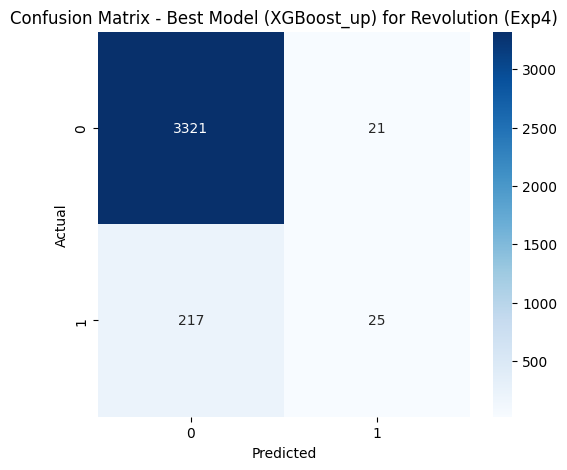


  --- ROC-AUC кривая для лучшей модели (XGBoost_up) ---


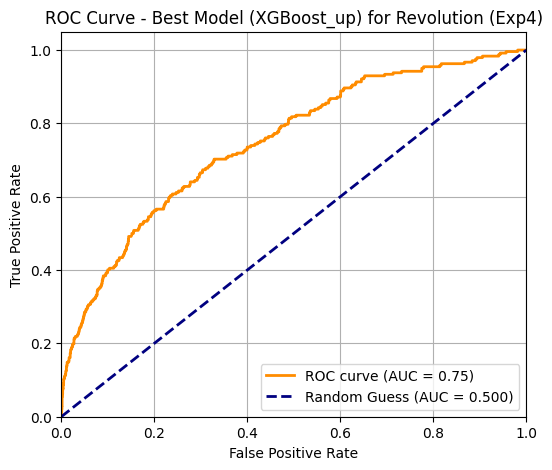


  --- Важность признаков для лучшей модели (XGBoost_up) ---


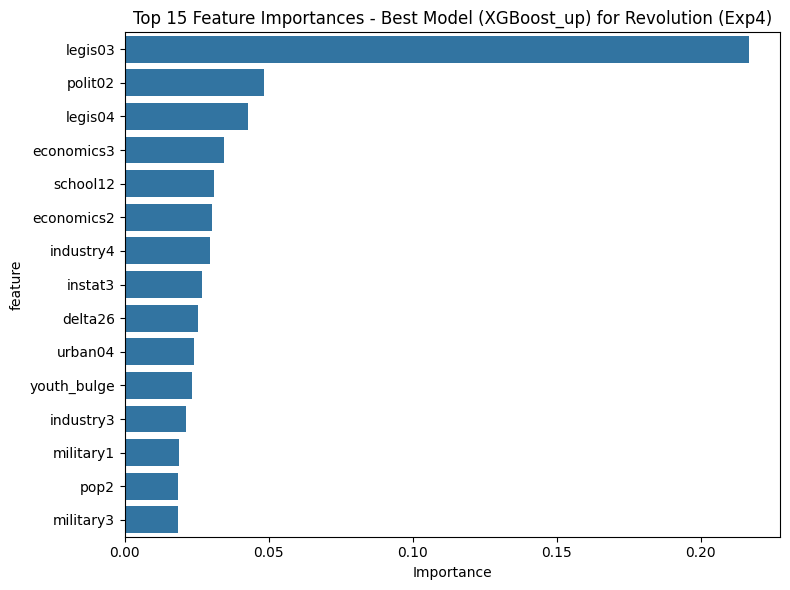

  График важности признаков показан.
    feature  importance
    legis03      0.2168
    polit02      0.0482
    legis04      0.0429
 economics3      0.0345
   school12      0.0311
 economics2      0.0304
  industry4      0.0296
    instat3      0.0267
    delta26      0.0253
    urban04      0.0239
youth_bulge      0.0235
  industry3      0.0214
  military1      0.0188
       pop2      0.0186
  military3      0.0186

--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp4) ---


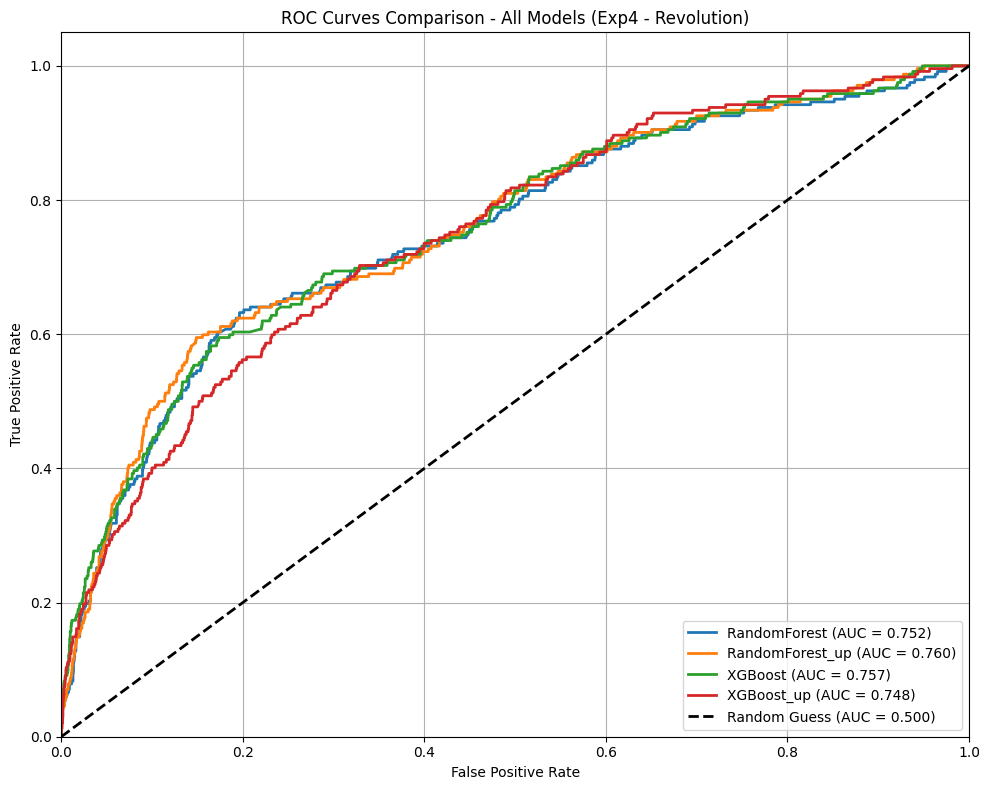

  Сводный график ROC-AUC для всех моделей Exp4 показан.

--- Эксперимент 4 завершен ---


In [ ]:
# --- Блок 5: Эксперимент 4 - Четвертое поколение (количественный и сравнительный анализ) ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Теория: Количественный и сравнительный анализ (Skocpol, Tilly, Goldstone) ---
# --- Модели: RandomForest, XGBoost (базовые и с подобранными гиперпараметрами через Optuna) ---
# --- Использует только df_cleaned ---
# --- МЯГКАЯ ОЧИСТКА ДАННЫХ ---
# --- ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ВНУТРИ БЛОКА (30 испытаний на модель) ---
# --- ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО F1-SCORE КЛАССА 1 ---
print("\n" + "="*60)
print("--- Эксперимент 4: Четвертое поколение (количественный анализ) ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Подготовка данных из df_cleaned ---
print("--- Шаг 1: Подготовка данных из df_cleaned ---")
try:
    df_shape = df_cleaned.shape
    print(f"Используется датафрейм df_cleaned. Размерность: {df_shape}")
except NameError:
    print("ОШИБКА: Переменная 'df_cleaned' не определена.")
    raise

# Убедимся, что целевая переменная существует
if 'revolution_occurred' not in df_cleaned.columns and 'domestic7' in df_cleaned.columns:
    df_cleaned['revolution_occurred'] = (df_cleaned['domestic7'] > 0).astype(int)
    print("Создана переменная 'revolution_occurred'.")

# --- 2. Определение признаков (Эксперимент 4 - Количественный анализ БЕЗ мультиколлинеарности) ---
print("\n--- Шаг 2: Определение признаков Эксперимента 4 (БЕЗ мультиколлинеарности) ---")
# Признаки согласно теории четвертого поколения (количественный и сравнительный анализ):
# Экономические факторы, социальные индикаторы, политические характеристики,
# международные связи, структура протеста, успешность предыдущих движений
# --- ИСКЛЮЧЕНЫ: domestic9, domestic6, domestic8 (мультиколлинеарность/утечка данных) ---
features_exp4 = [
    # Экономические факторы
    'economics2', # Gross Domestic Product Per Capita (Factor Cost)
    'economics3', # Gross National Product Per Capita (Market Prices)
    'economics4', # Currency in Circulation Per Capita (Scaling: 0.01)
    'delta32',    # % Annual Increase: Gross Domestic Product Per Capita (Scaling: 0.01)
    'economics6', # Official/Princial Exchange Rate Local Currency/$US (Scaling: 0.01)
    'economics7', # Free/Black Market Rate Local Currency Per $US (Scaling: 0.01)
    'revexp4',    # Nat'l Gov't Revenue Per Capita (Scaling: 0.01)
    'revexp6',    # Nat'l Gov't Expenditure Per Capita (Scaling: 0.01)
    'delta05',    # % Annual Increase: National Government Revenue Per Capita (Scaling: 0.01)
    'delta06',    # % Annual Increase: National Government Expenditure Per Capita (Scaling: 0.01)

    # Социальные индикаторы
    'school12',    # Percent Literate (Scaling: 0.1)
    'school09',    # University Enrollment Per Capita (Scaling: 0.0001)
    'urban02',     # Population Cities of 100000 & Over Per Capita (Scaling: 0.001)
    'urban04',     # Population Cities of 50000 & Over Per Capita (Scaling: 0.001)
    'pop2',        # Population Density (Scaling: 0.1)
    'delta01',     # % Annual Increase: Population (Scaling: 0.01)
    'delta03',     # % Annual Increase: Population Cities of 100000 & Over Per Capita (Scaling: 0.01)

    # Политические характеристики (БЕЗ прямых индикаторов конфликта)
    'polit02',     # Type of Regime
    'legis03',     # Effectiveness of Legislature
    'legis04',     # Competitiveness of Nominating Process
    # 'domestic9',   # Weighted Conflict Index - ИСКЛЮЧЕН (мультиколлинеарность)
    # 'domestic6',   # Riots - ИСКЛЮЧЕН (мультиколлинеарность)
    # 'domestic8',   # Anti-Government Demonstrations - ИСКЛЮЧЕН (мультиколлинеарность)
    'electoral1',  # Percent Voter Turnout Legislature (Scaling: 0.1)

    # Международные связи
    'trade2',      # Imports Per Capita (Scaling: 0.01)
    'trade4',      # Exports Per Capita (Scaling: 0.01)
    'instat3',     # International Status Composite Score
    'instat5',     # International Status Quintile
    'military1',   # National Defense Expenditure (Scaling: 10000)
    'military2',   # National Defense Expenditure Per Capita (Scaling: 0.01)

    # Военные факторы
    'military4',   # Size of Military/Population (Scaling: 0.0001)
    'military3',   # Size of Military (Scaling: 1000)

    # Структура производства
    'industry1',  # Percent GDP Originating in Industrial Activity
    'industry3',  # Percent Work Force in Agriculture (Scaling: 0.1)
    'industry4',  # Percent Work in Industry (Scaling: 0.1)
    'delta24',   # % Annual Increase: Percent GDP Originating in Industrial Activity (Scaling: 0.01)
    'delta25',   # % Annual Increase: Per Capita GDP Originating in Industrial Activity (Scaling: 0.01)
    'delta26',   # % Annual Increase: Percent Work Force in Agriculture (Scaling: 0.01)
    'delta27',   # % Annual Increase: Percent Work Force in Industry (Scaling: 0.01)
]

# Проверка наличия признаков
available_features_exp4 = [f for f in features_exp4 if f in df_cleaned.columns]
missing_features_exp4 = [f for f in features_exp4 if f not in df_cleaned.columns]
if missing_features_exp4:
    print(f"Предупреждение: Следующие признаки отсутствуют в df_cleaned: {missing_features_exp4}")
print(f"Используемые признаки ({len(available_features_exp4)}): {available_features_exp4}")

# Создание производных переменных (БЕЗ domestic*)
df_cleaned['black_market_premium'] = df_cleaned.get('economics7', 0) - df_cleaned.get('economics6', 0)
df_cleaned['fiscal_balance'] = df_cleaned.get('revexp4', 0) - df_cleaned.get('revexp6', 0)
df_cleaned['youth_bulge'] = df_cleaned.get('school09', 0) / (df_cleaned.get('school12', 1) + 1e-8)
df_cleaned['socioeconomic_stress'] = df_cleaned['black_market_premium'] * (1 - df_cleaned.get('school12', 0)/100)
# Косвенная оценка политической нестабильности (БЕЗ domestic*)
df_cleaned['political_instability_indirect'] = (
    (1 / (df_cleaned.get('polit02', 1) + 1e-8)) * # Обратная зависимость от типа режима
    (1 - df_cleaned.get('legis03', 0)) * # Обратная зависимость от эффективности
    df_cleaned.get('instat3', 0) # Прямая зависимость от международного статуса
)
df_cleaned['state_capacity'] = (
    0.4 * df_cleaned.get('instat3', 0) +
    0.3 * df_cleaned.get('legis03', 0) +
    0.3 * df_cleaned.get('legis04', 0)
) * (1 / (df_cleaned.get('military4', 0) + 1e-8))
df_cleaned['modernization_index'] = df_cleaned.get('industry1', 0) - df_cleaned.get('industry3', 0)
df_cleaned['international_dependency'] = (df_cleaned.get('trade2', 0) + df_cleaned.get('trade4', 0)) / (df_cleaned.get('economics2', 0) + 1e-8)

# Финальный список признаков
feature_cols_exp4 = available_features_exp4 + [
    'black_market_premium', 'fiscal_balance', 'youth_bulge',
    'socioeconomic_stress', 'political_instability_indirect', 'state_capacity',
    'modernization_index', 'international_dependency'
]
feature_cols_exp4 = [col for col in feature_cols_exp4 if col in df_cleaned.columns]
print(f"Финальный список признаков ({len(feature_cols_exp4)}): {feature_cols_exp4}")

# --- 3. Подготовка данных для моделирования ---
print("\n--- Шаг 3: Подготовка данных для моделирования ---")
# МЯГКАЯ ОЧИСТКА: Удаляем строки ТОЛЬКО если отсутствуют ВСЕ ключевые переменные
required_for_drop = ['revolution_occurred', 'year'] + feature_cols_exp4
df_model_exp4 = df_cleaned.dropna(subset=required_for_drop, how='all')
df_model_exp4 = df_model_exp4.reset_index(drop=True)
print(f"Данные после МЯГКОЙ предобработки для Эксперимента 4: {df_cleaned.shape} -> {df_model_exp4.shape}")

if df_model_exp4.empty:
    raise ValueError("После МЯГКОЙ очистки данных не осталось записей для Эксперимента 4.")

# Заполнение пропусков МЕДИАНОЙ
X_exp4 = df_model_exp4[feature_cols_exp4]
X_exp4_filled = X_exp4.fillna(X_exp4.median(numeric_only=True))
print("Пропущенные значения в признаках заполнены медианой.")

# Сортировка по году
df_sorted_exp4 = pd.concat([X_exp4_filled, df_model_exp4[['revolution_occurred', 'year']]], axis=1).sort_values('year')
split_index = int(len(df_sorted_exp4) * 0.8)

X = df_sorted_exp4[feature_cols_exp4]
y_rev = df_sorted_exp4['revolution_occurred']

X_train_rev, X_test_rev = X.iloc[:split_index], X.iloc[split_index:]
y_train_rev, y_test_rev = y_rev.iloc[:split_index], y_rev.iloc[split_index:]

print(f"Размер обучающей выборки (Revolution): {X_train_rev.shape}")
print(f"Размер тестовой выборки (Revolution): {X_test_rev.shape}")
print(f"Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")

# --- 4. Определение функций оптимизации с Optuna ---
print("\n--- Шаг 4: Определение функций оптимизации Optuna ---")

# --- a) Objective для Random Forest (Revolution) ---
def objective_rf_rev_exp4(trial):
    """Целевая функция для оптимизации RandomForestClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для XGBoost (Revolution) ---
def objective_xgb_rev_exp4(trial):
    """Целевая функция для оптимизации XGBClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 5. Запуск оптимизации с Optuna ---
print("\n--- Шаг 5: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store_exp4 = {} # Для хранения лучших параметров

# --- a) Оптимизация Random Forest для Revolution ---
print("  Оптимизация Random Forest для Revolution...")
study_rf_rev_exp4 = optuna.create_study(direction='maximize')
study_rf_rev_exp4.optimize(objective_rf_rev_exp4, n_trials=30, show_progress_bar=False)
best_params_rf_rev_exp4 = study_rf_rev_exp4.best_params
best_params_store_exp4['RandomForest_up'] = best_params_rf_rev_exp4
print(f"    Лучшие параметры RF (Revolution): {best_params_rf_rev_exp4}")
print(f"    Лучший F1-Score (Class 1) (RF Revolution): {study_rf_rev_exp4.best_value:.4f}")

# --- b) Оптимизация XGBoost для Revolution ---
print("  Оптимизация XGBoost для Revolution...")
study_xgb_rev_exp4 = optuna.create_study(direction='maximize')
study_xgb_rev_exp4.optimize(objective_xgb_rev_exp4, n_trials=30, show_progress_bar=False)
best_params_xgb_rev_exp4 = study_xgb_rev_exp4.best_params
best_params_store_exp4['XGBoost_up'] = best_params_xgb_rev_exp4
print(f"    Лучшие параметры XGB (Revolution): {best_params_xgb_rev_exp4}")
print(f"    Лучший F1-Score (Class 1) (XGB Revolution): {study_xgb_rev_exp4.best_value:.4f}")

# --- 6. Обучение и оценка 4 моделей ---
print("\n--- Шаг 6: Обучение и оценка 4 моделей (Exp4) ---")
model_predictions_exp4 = {} # Для хранения прогнозов и моделей
exp4_results = {} # Для хранения метрик

# --- Модели для прогнозирования Revolution ---
print("\n--- Модели для прогнозирования Revolution (Exp4) ---")
print(f"  Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")
if y_train_rev.nunique() < 2:
    print("  Предупреждение: В обучающей выборке для Revolution только один класс.")
else:
    # Модель 4a: Random Forest (базовая)
    print("  Обучение Random Forest (базовая)...")
    model_rf_rev = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
    model_rf_rev.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf = model_rf_rev.predict(X_test_rev)
    y_pred_proba_rev_rf = model_rf_rev.predict_proba(X_test_rev)[:, 1]
    save_results("Exp4", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf, y_pred_proba_rev_rf)
    model_predictions_exp4['RandomForest'] = (y_pred_rev_rf, y_pred_proba_rev_rf, model_rf_rev)
    exp4_results['RandomForest_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf)
    exp4_results['RandomForest_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf)

    # Модель 4b: Random Forest (улучшенная)
    print("  Обучение Random Forest (улучшенная)...")
    best_params_rf_full_exp4 = {**best_params_rf_rev_exp4, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
    model_rf_up_rev = RandomForestClassifier(**best_params_rf_full_exp4)
    model_rf_up_rev.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf_up = model_rf_up_rev.predict(X_test_rev)
    y_pred_proba_rev_rf_up = model_rf_up_rev.predict_proba(X_test_rev)[:, 1]
    save_results("Exp4", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up, y_pred_proba_rev_rf_up)
    model_predictions_exp4['RandomForest_up'] = (y_pred_rev_rf_up, y_pred_proba_rev_rf_up, model_rf_up_rev)
    exp4_results['RandomForest_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf_up)
    exp4_results['RandomForest_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf_up)

    # Модель 4c: XGBoost (базовая)
    print("  Обучение XGBoost (базовая)...")
    model_xgb_rev = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    model_xgb_rev.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb = model_xgb_rev.predict(X_test_rev)
    y_pred_proba_rev_xgb = model_xgb_rev.predict_proba(X_test_rev)[:, 1]
    save_results("Exp4", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb, y_pred_proba_rev_xgb)
    model_predictions_exp4['XGBoost'] = (y_pred_rev_xgb, y_pred_proba_rev_xgb, model_xgb_rev)
    exp4_results['XGBoost_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb)
    exp4_results['XGBoost_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb)

    # Модель 4d: XGBoost (улучшенная)
    print("  Обучение XGBoost (улучшенная)...")
    best_params_xgb_full_exp4 = {**best_params_xgb_rev_exp4, 'random_state': 42, 'n_jobs': -1}
    model_xgb_up_rev = xgb.XGBClassifier(**best_params_xgb_full_exp4)
    model_xgb_up_rev.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb_up = model_xgb_up_rev.predict(X_test_rev)
    y_pred_proba_rev_xgb_up = model_xgb_up_rev.predict_proba(X_test_rev)[:, 1]
    save_results("Exp4", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up)
    model_predictions_exp4['XGBoost_up'] = (y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up, model_xgb_up_rev)
    exp4_results['XGBoost_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb_up)
    exp4_results['XGBoost_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb_up)

# --- 7. Сводка результатов Эксперимента 4 ---
print("\n--- Шаг 7: Сводка результатов Эксперимента 4 ---")
exp4_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp4' and r['Target'] == 'Revolution']

if exp4_rev_results:
    df_exp4_rev_summary = pd.DataFrame(exp4_rev_results)
    df_exp4_rev_summary = df_exp4_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp4), отсортированные по F1-Score (Class 1):")
    print(df_exp4_rev_summary.round(4).to_string(index=False))

# --- 8. Определение и анализ лучшей модели по F1-Score (Class 1) ---
print("\n--- Шаг 8: Анализ лучшей модели по F1-Score (Class 1) (Exp4) ---")
if exp4_rev_results:
    best_model_entry_exp4 = df_exp4_rev_summary.iloc[0] # Первая строка после сортировки по F1-Score (Class 1)
    best_model_name_exp4 = best_model_entry_exp4['Model']
    best_f1_class1_exp4 = best_model_entry_exp4['F1-Score (Class 1)']
    best_auc_exp4 = best_model_entry_exp4['AUC-ROC']
    best_acc_exp4 = best_model_entry_exp4['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1) (Exp4): {best_model_name_exp4}")
    print(f"    F1-Score (Class 1): {best_f1_class1_exp4:.4f}")
    print(f"    AUC-ROC: {best_auc_exp4:.4f}")
    print(f"    Accuracy: {best_acc_exp4:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best_exp4, y_pred_proba_best_exp4, model_best_exp4 = model_predictions_exp4[best_model_name_exp4]
    y_true_best_exp4 = y_test_rev

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name_exp4}) ---")
    try:
        report_best_exp4 = classification_report(y_true_best_exp4, y_pred_best_exp4, output_dict=True)
        df_report_best_exp4 = pd.DataFrame(report_best_exp4).transpose()
        print(df_report_best_exp4.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name_exp4}) ---")
    try:
        cm_best_exp4 = confusion_matrix(y_true_best_exp4, y_pred_best_exp4)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best_exp4, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name_exp4}) for Revolution (Exp4)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name_exp4}) ---")
    try:
        fpr_best_exp4, tpr_best_exp4, _ = roc_curve(y_true_best_exp4, y_pred_proba_best_exp4)
        auc_best_exp4 = roc_auc_score(y_true_best_exp4, y_pred_proba_best_exp4)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best_exp4, tpr_best_exp4, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_best_exp4:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name_exp4}) for Revolution (Exp4)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name_exp4}) ---")
    try:
        if hasattr(model_best_exp4, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance_exp4 = model_best_exp4.feature_importances_
            features_df_exp4 = pd.DataFrame({'feature': feature_cols_exp4, 'importance': feature_importance_exp4})
            features_df_exp4 = features_df_exp4.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp4)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name_exp4}) for Revolution (Exp4)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df_exp4.round(4).to_string(index=False))

        elif hasattr(model_best_exp4, 'coef_'):
            # Для линейных моделей (LogisticRegression) - этот блок не выполнится
            # но оставлен для полноты, если в будущем добавится LR
            coef_importance_exp4 = np.abs(model_best_exp4.coef_[0]) # Берем абсолютные значения коэффициентов
            features_df_exp4 = pd.DataFrame({'feature': feature_cols_exp4, 'importance': coef_importance_exp4})
            features_df_exp4 = features_df_exp4.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp4)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name_exp4}) for Revolution (Exp4)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df_exp4.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 9. Сводный ROC-AUC график для всех 4 моделей ---
print("\n--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp4) ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors # Используем палитру из 10 цветов
    model_color_map = dict(zip(model_predictions_exp4.keys(), colors[:len(model_predictions_exp4)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp4.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp4 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей Exp4 показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 4 завершен ---")



--- Эксперимент 5: Пятое поколение (цифровизация, молодежь) ---
--- Шаг 1: Подготовка данных из df_cleaned ---
Используется датафрейм df_cleaned. Размерность: (17916, 206)

--- Шаг 2: Определение признаков Эксперимента 5 ---
Используемые признаки (27): ['computer1', 'computer2', 'computer3', 'computer4', 'computer5', 'computer6', 'media3', 'media4', 'phone2', 'phone5', 'school08', 'school09', 'delta01', 'pop2', 'urban02', 'urban04', 'urban06', 'urban08', 'delta03', 'delta04', 'trade2', 'trade4', 'instat3', 'instat5', 'military1', 'media7', 'electoral1']
Финальный список признаков (32): ['computer1', 'computer2', 'computer3', 'computer4', 'computer5', 'computer6', 'media3', 'media4', 'phone2', 'phone5', 'school08', 'school09', 'delta01', 'pop2', 'urban02', 'urban04', 'urban06', 'urban08', 'delta03', 'delta04', 'trade2', 'trade4', 'instat3', 'instat5', 'military1', 'media7', 'electoral1', 'digital_index', 'youth_bulge', 'transnational_connectivity', 'digital_mobilization', 'diffusion_ri

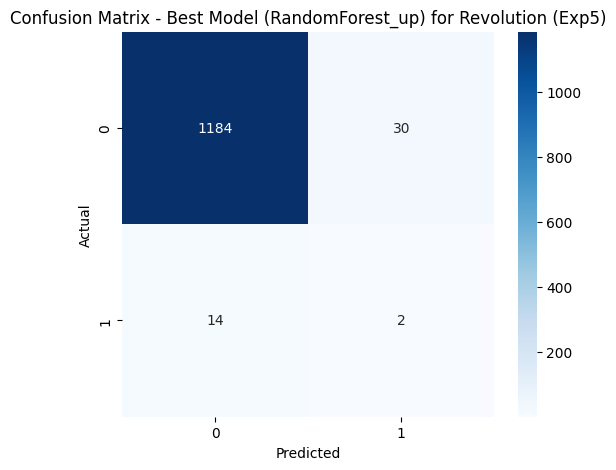


  --- ROC-AUC кривая для лучшей модели (RandomForest_up) ---


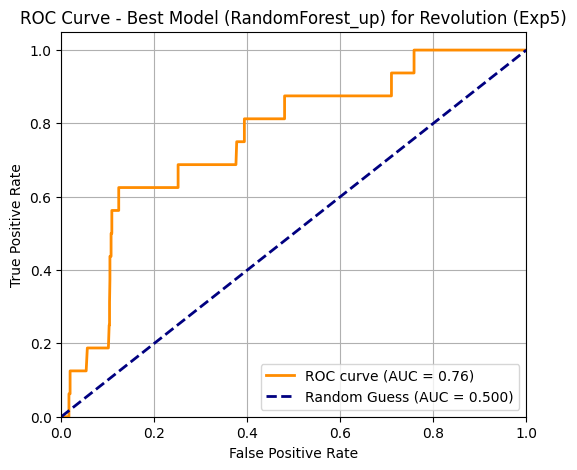


  --- Важность признаков для лучшей модели (RandomForest_up) ---


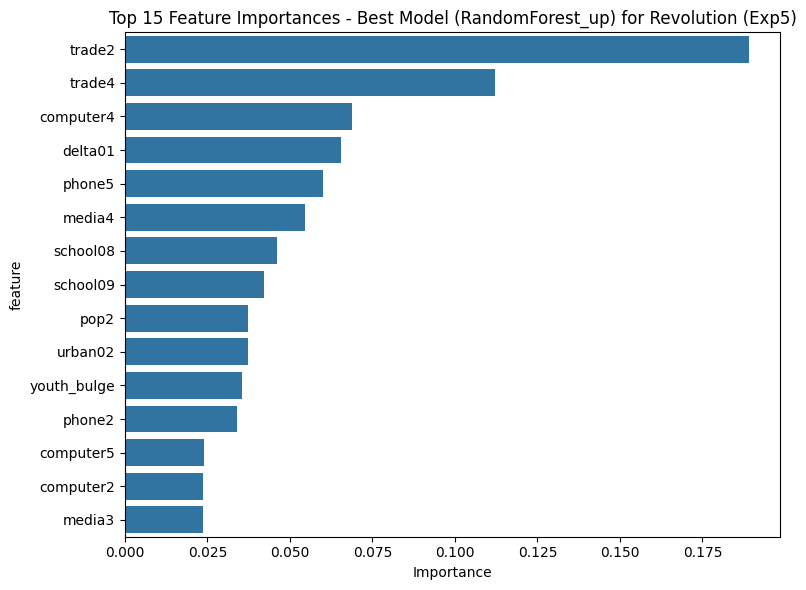

  График важности признаков показан.
    feature  importance
     trade2      0.1890
     trade4      0.1120
  computer4      0.0689
    delta01      0.0655
     phone5      0.0600
     media4      0.0545
   school08      0.0462
   school09      0.0422
       pop2      0.0373
    urban02      0.0372
youth_bulge      0.0356
     phone2      0.0341
  computer5      0.0239
  computer2      0.0236
     media3      0.0235

--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp5) ---


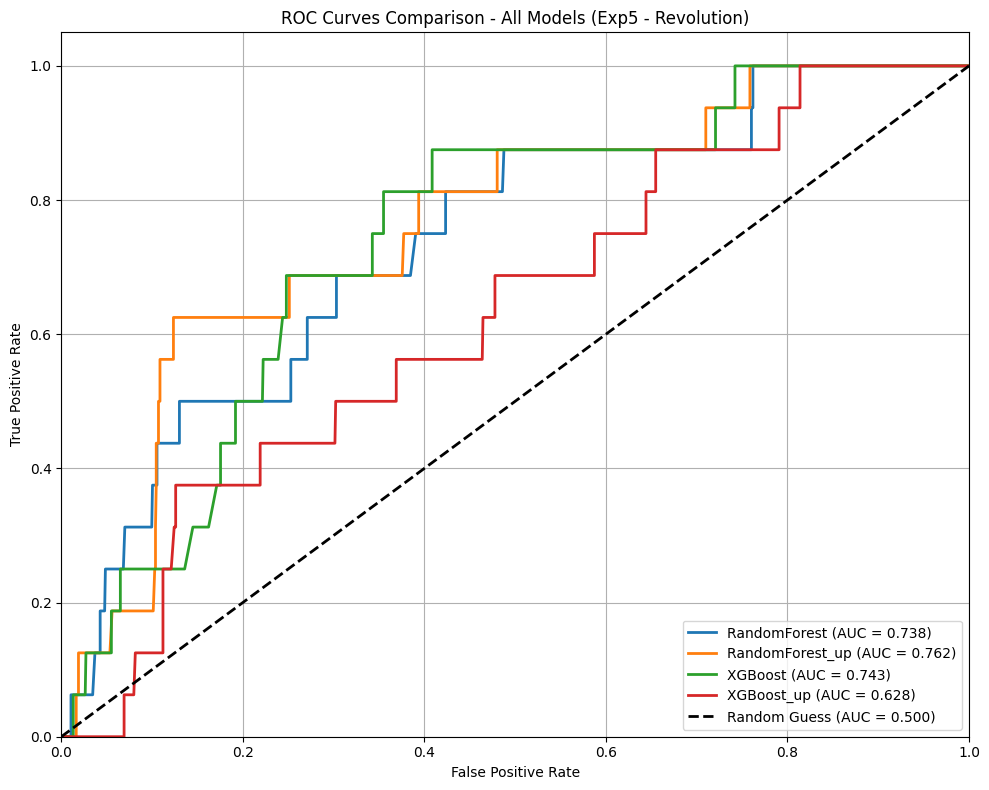

  Сводный график ROC-AUC для всех моделей Exp5 показан.

--- Эксперимент 5 завершен ---


In [ ]:
# --- Блок 6: Эксперимент 5 - Пятое поколение ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Теория: Цифровизация, молодежный фактор, транснациональная диффузия (Beissinger, Chenoweth, Pinckney) ---
# --- Модели: RandomForest, XGBoost (базовые и с подобранными гypерпараметрами через Optuna) ---
# --- Использует только df_cleaned ---
# --- МЯГКАЯ ОЧИСТКА ДАННЫХ ---
# --- ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ВНУТРИ БЛОКА (30 испытаний на модель) ---
# --- ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО F1-SCORE КЛАССА 1 ---
print("\n" + "="*60)
print("--- Эксперимент 5: Пятое поколение (цифровизация, молодежь) ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Подготовка данных из df_cleaned ---
print("--- Шаг 1: Подготовка данных из df_cleaned ---")
try:
    df_shape = df_cleaned.shape
    print(f"Используется датафрейм df_cleaned. Размерность: {df_shape}")
except NameError:
    print("ОШИБКА: Переменная 'df_cleaned' не определена.")
    raise

# Убедимся, что целевая переменная существует
if 'revolution_occurred' not in df_cleaned.columns and 'domestic7' in df_cleaned.columns:
    df_cleaned['revolution_occurred'] = (df_cleaned['domestic7'] > 0).astype(int)
    print("Создана переменная 'revolution_occurred'.")

# --- 2. Определение признаков (Эксперимент 5 - Цифровизация, молодежь) ---
print("\n--- Шаг 2: Определение признаков Эксперимента 5 ---")
# Признаки согласно теории пятого поколения (цифровизация, молодежь, диффузия)
# Фокус на XXI век (1990+)
features_exp5 = [
    # Цифровизация и коммуникации
    'computer1', 'computer2', 'computer3', 'computer4', 'computer5', 'computer6',
    'media3', 'media4', 'phone2', 'phone5',
    # Молодежный фактор и урбанизация
    'school08', 'school09', 'delta01', 'pop2', 'urban02', 'urban04', 'urban06', 'urban08', 'delta03', 'delta04',
    # Транснациональная диффузия
    'trade2', 'trade4', 'instat3', 'instat5', 'military1', 'media7',
    # Ненасильственные протесты (БЕЗ прямых индикаторов конфликта)
    # 'domestic8',  # Anti-Government Demonstrations - ИСКЛЮЧЕН (мультиколлинеарность)
    # 'domestic2',  # General Strikes - ИСКЛЮЧЕН (мультиколлинеарность)
    'electoral1', # Percent Voter Turnout Legislature (Scaling: 0.1)
    # 'domestic9',  # Weighted Conflict Index - ИСКЛЮЧЕН (мультиколлинеарность)
    # 'domestic6',  # Riots - ИСКЛЮЧЕН (мультиколлинеарность)
]

# Проверка наличия признаков
available_features_exp5 = [f for f in features_exp5 if f in df_cleaned.columns]
missing_features_exp5 = [f for f in features_exp5 if f not in df_cleaned.columns]
if missing_features_exp5:
    print(f"Предупреждение: Следующие признаки отсутствуют в df_cleaned: {missing_features_exp5}")
print(f"Используемые признаки ({len(available_features_exp5)}): {available_features_exp5}")

# Создание производных переменных (БЕЗ domestic*)
df_cleaned['digital_index'] = (
    0.3 * df_cleaned.get('computer4', 0) +
    0.2 * df_cleaned.get('computer6', 0) +
    0.3 * df_cleaned.get('phone5', 0) +
    0.2 * df_cleaned.get('media4', 0)
)
df_cleaned['youth_bulge'] = df_cleaned.get('school09', 0) / (df_cleaned.get('school12', 1) + 1e-8)
df_cleaned['transnational_connectivity'] = (
    (df_cleaned.get('trade2', 0) + df_cleaned.get('trade4', 0)) *
    df_cleaned.get('instat3', 0) /
    (df_cleaned.get('economics2', 0) + 1e-8)
)
df_cleaned['digital_mobilization'] = df_cleaned['digital_index'] * df_cleaned['youth_bulge']
df_cleaned['diffusion_risk'] = df_cleaned['transnational_connectivity'] * df_cleaned.get('electoral1', 0)

# Финальный список признаков
feature_cols_exp5 = available_features_exp5 + [
    'digital_index', 'youth_bulge', 'transnational_connectivity',
    'digital_mobilization', 'diffusion_risk'
]
feature_cols_exp5 = [col for col in feature_cols_exp5 if col in df_cleaned.columns]
print(f"Финальный список признаков ({len(feature_cols_exp5)}): {feature_cols_exp5}")

# --- 3. Подготовка данных для моделирования ---
print("\n--- Шаг 3: Подготовка данных для моделирования ---")
# Фильтрация по периоду XXI века
df_clean_exp5 = df_cleaned[df_cleaned['year'] >= 1990].copy()
print(f"Данные отфильтрованы по периоду 1990+. Размерность: {df_cleaned.shape} -> {df_clean_exp5.shape}")

# МЯГКАЯ ОЧИСТКА: Удаляем строки ТОЛЬКО если отсутствуют ВСЕ ключевые переменные
required_for_drop = ['revolution_occurred', 'year'] + feature_cols_exp5
df_model_exp5 = df_clean_exp5.dropna(subset=required_for_drop, how='all')
df_model_exp5 = df_model_exp5.reset_index(drop=True)
print(f"Данные после МЯГКОЙ предобработки для Эксперимента 5: {df_clean_exp5.shape} -> {df_model_exp5.shape}")

if df_model_exp5.empty:
    raise ValueError("После МЯГКОЙ очистки данных не осталось записей для Эксперимента 5.")

# Заполнение пропусков МЕДИАНОЙ
X_exp5 = df_model_exp5[feature_cols_exp5]
X_exp5_filled = X_exp5.fillna(X_exp5.median(numeric_only=True))
print("Пропущенные значения в признаках заполнены медианой.")

# Сортировка по году
df_sorted_exp5 = pd.concat([X_exp5_filled, df_model_exp5[['revolution_occurred', 'year']]], axis=1).sort_values('year')
split_index = int(len(df_sorted_exp5) * 0.8)

X = df_sorted_exp5[feature_cols_exp5]
y_rev = df_sorted_exp5['revolution_occurred']

X_train_rev, X_test_rev = X.iloc[:split_index], X.iloc[split_index:]
y_train_rev, y_test_rev = y_rev.iloc[:split_index], y_rev.iloc[split_index:]

print(f"Размер обучающей выборки (Revolution): {X_train_rev.shape}")
print(f"Размер тестовой выборки (Revolution): {X_test_rev.shape}")
print(f"Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")

# --- 4. Определение функций оптимизации с Optuna ---
print("\n--- Шаг 4: Определение функций оптимизации Optuna ---")

# --- a) Objective для Random Forest (Revolution) ---
def objective_rf_rev_exp5(trial):
    """Целевая функция для оптимизации RandomForestClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для XGBoost (Revolution) ---
def objective_xgb_rev_exp5(trial):
    """Целевая функция для оптимизации XGBClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 5. Запуск оптимизации с Optuna ---
print("\n--- Шаг 5: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store_exp5 = {} # Для хранения лучших параметров

# --- a) Оптимизация Random Forest для Revolution ---
print("  Оптимизация Random Forest для Revolution...")
study_rf_rev_exp5 = optuna.create_study(direction='maximize')
study_rf_rev_exp5.optimize(objective_rf_rev_exp5, n_trials=30, show_progress_bar=False)
best_params_rf_rev_exp5 = study_rf_rev_exp5.best_params
best_params_store_exp5['RandomForest_up'] = best_params_rf_rev_exp5
print(f"    Лучшие параметры RF (Revolution): {best_params_rf_rev_exp5}")
print(f"    Лучший F1-Score (Class 1) (RF Revolution): {study_rf_rev_exp5.best_value:.4f}")

# --- b) Оптимизация XGBoost для Revolution ---
print("  Оптимизация XGBoost для Revolution...")
study_xgb_rev_exp5 = optuna.create_study(direction='maximize')
study_xgb_rev_exp5.optimize(objective_xgb_rev_exp5, n_trials=30, show_progress_bar=False)
best_params_xgb_rev_exp5 = study_xgb_rev_exp5.best_params
best_params_store_exp5['XGBoost_up'] = best_params_xgb_rev_exp5
print(f"    Лучшие параметры XGB (Revolution): {best_params_xgb_rev_exp5}")
print(f"    Лучший F1-Score (Class 1) (XGB Revolution): {study_xgb_rev_exp5.best_value:.4f}")

# --- 6. Обучение и оценка 4 моделей ---
print("\n--- Шаг 6: Обучение и оценка 4 моделей (Exp5) ---")
model_predictions_exp5 = {} # Для хранения прогнозов и моделей
exp5_results = {} # Для хранения метрик

# --- Модели для прогнозирования Revolution ---
print("\n--- Модели для прогнозирования Revolution (Exp5) ---")
print(f"  Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")
if y_train_rev.nunique() < 2:
    print("  Предупреждение: В обучающей выборке для Revolution только один класс.")
else:
    # Модель 5a: Random Forest (базовая)
    print("  Обучение Random Forest (базовая)...")
    model_rf_rev_exp5 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
    model_rf_rev_exp5.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf = model_rf_rev_exp5.predict(X_test_rev)
    y_pred_proba_rev_rf = model_rf_rev_exp5.predict_proba(X_test_rev)[:, 1]
    save_results("Exp5", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf, y_pred_proba_rev_rf)
    model_predictions_exp5['RandomForest'] = (y_pred_rev_rf, y_pred_proba_rev_rf, model_rf_rev_exp5)
    exp5_results['RandomForest_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf)
    exp5_results['RandomForest_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf)
    exp5_results['RandomForest_F1_1'] = classification_report(y_test_rev, y_pred_rev_rf, output_dict=True)['1']['f1-score']

    # Модель 5b: Random Forest (улучшенная)
    print("  Обучение Random Forest (улучшенная)...")
    best_params_rf_full_exp5 = {**best_params_rf_rev_exp5, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
    model_rf_up_rev_exp5 = RandomForestClassifier(**best_params_rf_full_exp5)
    model_rf_up_rev_exp5.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf_up = model_rf_up_rev_exp5.predict(X_test_rev)
    y_pred_proba_rev_rf_up = model_rf_up_rev_exp5.predict_proba(X_test_rev)[:, 1]
    save_results("Exp5", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up, y_pred_proba_rev_rf_up)
    model_predictions_exp5['RandomForest_up'] = (y_pred_rev_rf_up, y_pred_proba_rev_rf_up, model_rf_up_rev_exp5)
    exp5_results['RandomForest_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf_up)
    exp5_results['RandomForest_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf_up)
    exp5_results['RandomForest_up_F1_1'] = classification_report(y_test_rev, y_pred_rev_rf_up, output_dict=True)['1']['f1-score']

    # Модель 5c: XGBoost (базовая)
    print("  Обучение XGBoost (базовая)...")
    model_xgb_rev_exp5 = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    model_xgb_rev_exp5.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb = model_xgb_rev_exp5.predict(X_test_rev)
    y_pred_proba_rev_xgb = model_xgb_rev_exp5.predict_proba(X_test_rev)[:, 1]
    save_results("Exp5", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb, y_pred_proba_rev_xgb)
    model_predictions_exp5['XGBoost'] = (y_pred_rev_xgb, y_pred_proba_rev_xgb, model_xgb_rev_exp5)
    exp5_results['XGBoost_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb)
    exp5_results['XGBoost_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb)
    exp5_results['XGBoost_F1_1'] = classification_report(y_test_rev, y_pred_rev_xgb, output_dict=True)['1']['f1-score']

    # Модель 5d: XGBoost (улучшенная)
    print("  Обучение XGBoost (улучшенная)...")
    best_params_xgb_full_exp5 = {**best_params_xgb_rev_exp5, 'random_state': 42, 'n_jobs': -1}
    model_xgb_up_rev_exp5 = xgb.XGBClassifier(**best_params_xgb_full_exp5)
    model_xgb_up_rev_exp5.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb_up = model_xgb_up_rev_exp5.predict(X_test_rev)
    y_pred_proba_rev_xgb_up = model_xgb_up_rev_exp5.predict_proba(X_test_rev)[:, 1]
    save_results("Exp5", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up)
    model_predictions_exp5['XGBoost_up'] = (y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up, model_xgb_up_rev_exp5)
    exp5_results['XGBoost_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb_up)
    exp5_results['XGBoost_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb_up)
    exp5_results['XGBoost_up_F1_1'] = classification_report(y_test_rev, y_pred_rev_xgb_up, output_dict=True)['1']['f1-score']

# --- 7. Сводка результатов Эксперимента 5 ---
print("\n--- Шаг 7: Сводка результатов Эксперимента 5 ---")
exp5_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp5' and r['Target'] == 'Revolution']

if exp5_rev_results:
    df_exp5_rev_summary = pd.DataFrame(exp5_rev_results)
    df_exp5_rev_summary = df_exp5_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp5), отсортированные по F1-Score (Class 1):")
    print(df_exp5_rev_summary.round(4).to_string(index=False))

# --- 8. Определение и анализ лучшей модели по F1-Score (Class 1) ---
print("\n--- Шаг 8: Анализ лучшей модели по F1-Score (Class 1) (Exp5) ---")
if exp5_rev_results:
    best_model_entry_exp5 = df_exp5_rev_summary.iloc[0] # Первая строка после сортировки по F1-Score (Class 1)
    best_model_name_exp5 = best_model_entry_exp5['Model']
    best_f1_class1_exp5 = best_model_entry_exp5['F1-Score (Class 1)']
    best_auc_exp5 = best_model_entry_exp5['AUC-ROC']
    best_acc_exp5 = best_model_entry_exp5['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1) (Exp5): {best_model_name_exp5}")
    print(f"    F1-Score (Class 1): {best_f1_class1_exp5:.4f}")
    print(f"    AUC-ROC: {best_auc_exp5:.4f}")
    print(f"    Accuracy: {best_acc_exp5:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best_exp5, y_pred_proba_best_exp5, model_best_exp5 = model_predictions_exp5[best_model_name_exp5]
    y_true_best_exp5 = y_test_rev

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name_exp5}) ---")
    try:
        report_best_exp5 = classification_report(y_true_best_exp5, y_pred_best_exp5, output_dict=True)
        df_report_best_exp5 = pd.DataFrame(report_best_exp5).transpose()
        print(df_report_best_exp5.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name_exp5}) ---")
    try:
        cm_best_exp5 = confusion_matrix(y_true_best_exp5, y_pred_best_exp5)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best_exp5, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name_exp5}) for Revolution (Exp5)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name_exp5}) ---")
    try:
        fpr_best_exp5, tpr_best_exp5, _ = roc_curve(y_true_best_exp5, y_pred_proba_best_exp5)
        auc_best_exp5 = roc_auc_score(y_true_best_exp5, y_pred_proba_best_exp5)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best_exp5, tpr_best_exp5, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_best_exp5:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name_exp5}) for Revolution (Exp5)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name_exp5}) ---")
    try:
        if hasattr(model_best_exp5, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance_exp5 = model_best_exp5.feature_importances_
            features_df_exp5 = pd.DataFrame({'feature': feature_cols_exp5, 'importance': feature_importance_exp5})
            features_df_exp5 = features_df_exp5.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp5)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name_exp5}) for Revolution (Exp5)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df_exp5.round(4).to_string(index=False))

        elif hasattr(model_best_exp5, 'coef_'):
            # Для линейных моделей (LogisticRegression) - этот блок не выполнится
            # но оставлен для полноты, если в будущем добавится LR
            coef_importance_exp5 = np.abs(model_best_exp5.coef_[0]) # Берем абсолютные значения коэффициентов
            features_df_exp5 = pd.DataFrame({'feature': feature_cols_exp5, 'importance': coef_importance_exp5})
            features_df_exp5 = features_df_exp5.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp5)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name_exp5}) for Revolution (Exp5)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df_exp5.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 9. Сводный ROC-AUC график для всех 4 моделей ---
print("\n--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp5) ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors # Используем палитру из 10 цветов
    model_color_map = dict(zip(model_predictions_exp5.keys(), colors[:len(model_predictions_exp5)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp5.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp5 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей Exp5 показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 5 завершен ---")



--- Эксперимент 6: Шестое поколение (системный и процессуальный подход) ---
--- Шаг 1: Подготовка данных из df_cleaned ---
Используется датафрейм df_cleaned. Размерность: (17916, 214)

--- Шаг 2: Определение признаков Эксперимента 6 (БЕЗ мультиколлинеарности) ---
Используемые признаки (25): ['polit10', 'legis02', 'polit01', 'polit11', 'polit12', 'legis01', 'legis07', 'legis03', 'legis04', 'economics2', 'delta32', 'revexp4', 'revexp6', 'military2', 'military4', 'industry3', 'industry4', 'trade2', 'trade4', 'school12', 'school09', 'urban02', 'delta01', 'instat3', 'instat5']
Финальный список признаков (36): ['polit10', 'legis02', 'polit01', 'polit11', 'polit12', 'legis01', 'legis07', 'legis03', 'legis04', 'economics2', 'delta32', 'revexp4', 'revexp6', 'military2', 'military4', 'industry3', 'industry4', 'trade2', 'trade4', 'school12', 'school09', 'urban02', 'delta01', 'instat3', 'instat5', 'elite_production', 'elite_cohesion', 'fiscal_balance', 'system_efficiency', 'social_mobility', 'you

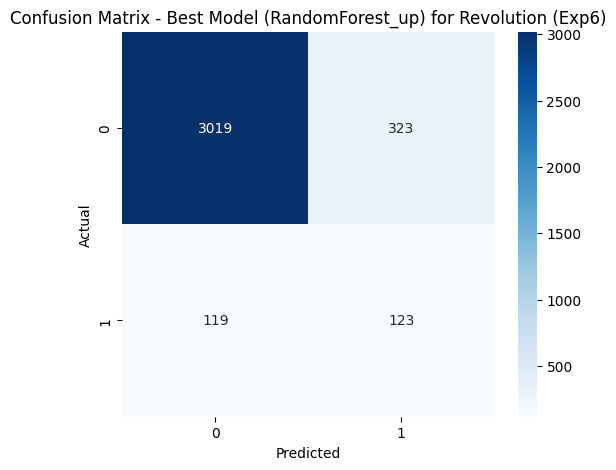


  --- ROC-AUC кривая для лучшей модели (RandomForest_up) ---


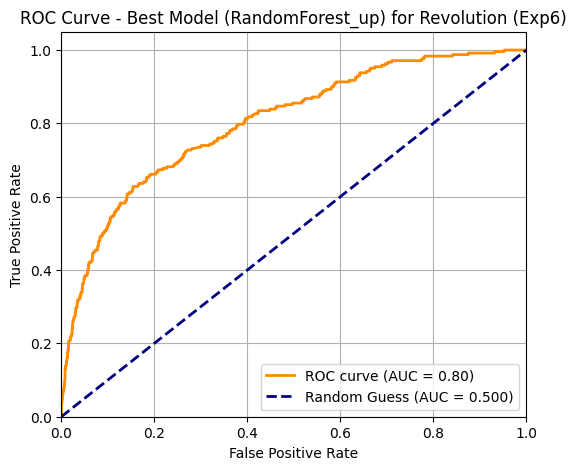


  --- Важность признаков для лучшей модели (RandomForest_up) ---


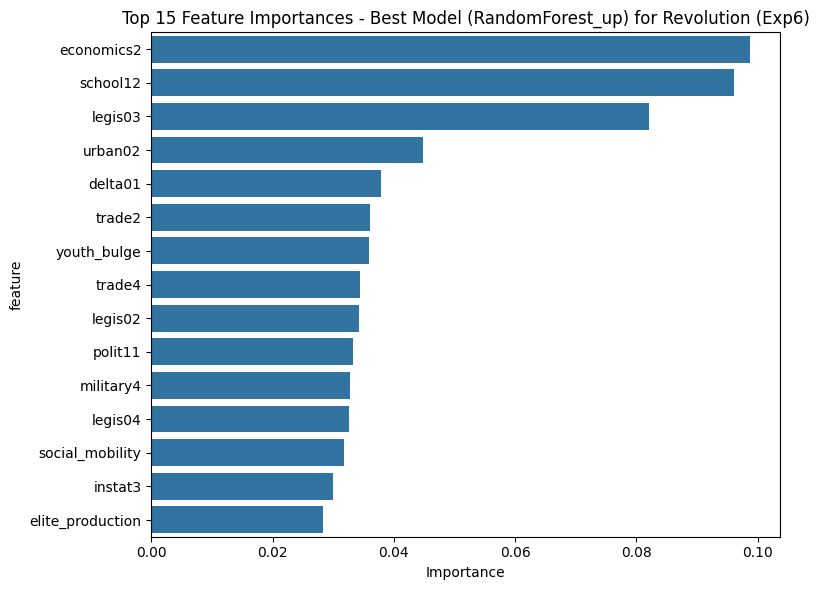

  График важности признаков показан.
         feature  importance
      economics2      0.0987
        school12      0.0961
         legis03      0.0820
         urban02      0.0447
         delta01      0.0378
          trade2      0.0361
     youth_bulge      0.0359
          trade4      0.0344
         legis02      0.0343
         polit11      0.0332
       military4      0.0328
         legis04      0.0325
 social_mobility      0.0318
         instat3      0.0300
elite_production      0.0283

--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp6) ---


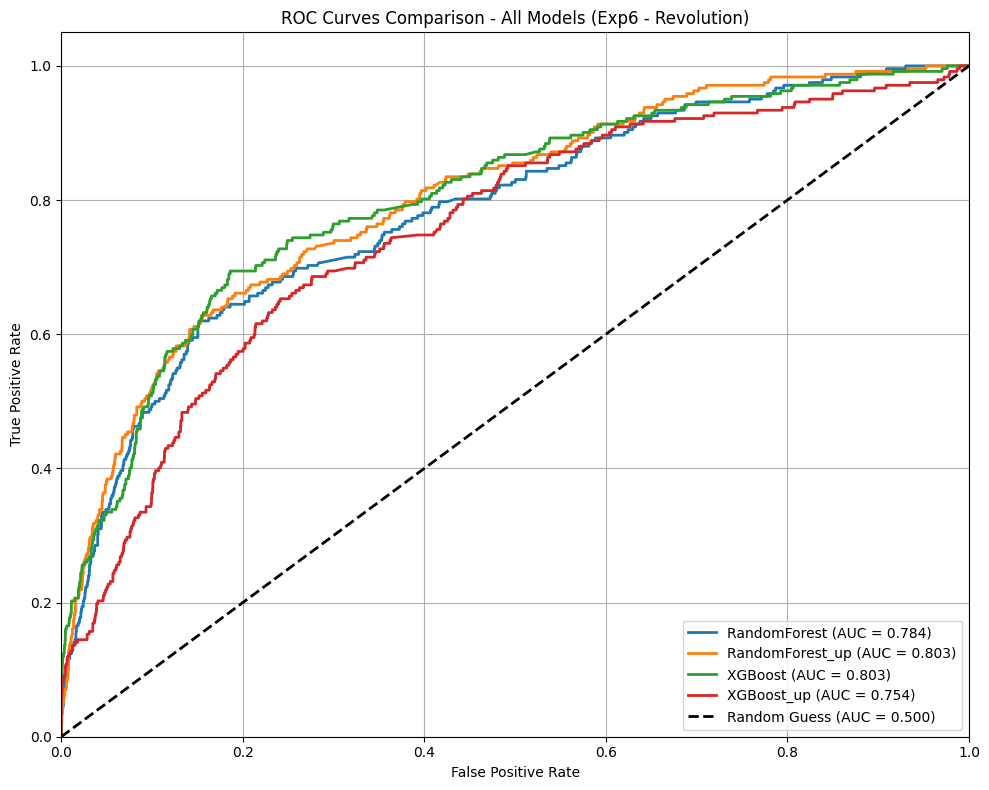

  Сводный график ROC-AUC для всех моделей Exp6 показан.

--- Эксперимент 6 завершен ---


In [ ]:
# --- Блок 7: Эксперимент 6 - Шестое поколение (системный и процессуальный подход) ---
# --- Цель: Прогнозирование революций (domestic7 > 0) ---
# --- Теория: Системный и процессуальный подход (Дождиков) ---
# --- Модели: RandomForest, XGBoost (базовые и с подобранными гиперпараметрами через Optuna) ---
# --- Использует только df_cleaned ---
# --- МЯГКАЯ ОЧИСТКА ДАННЫХ ---
# --- ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ВНУТРИ БЛОКА (30 испытаний на модель) ---
# --- ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО F1-SCORE КЛАССА 1 ---
print("\n" + "="*60)
print("--- Эксперимент 6: Шестое поколение (системный и процессуальный подход) ---")
print("="*60)

# --- Импорт Optuna ---
import optuna
# Отключаем логи Optuna для чистоты вывода
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Подготовка данных из df_cleaned ---
print("--- Шаг 1: Подготовка данных из df_cleaned ---")
try:
    df_shape = df_cleaned.shape
    print(f"Используется датафрейм df_cleaned. Размерность: {df_shape}")
except NameError:
    print("ОШИБКА: Переменная 'df_cleaned' не определена.")
    raise

# Убедимся, что целевая переменная существует
if 'revolution_occurred' not in df_cleaned.columns and 'domestic7' in df_cleaned.columns:
    df_cleaned['revolution_occurred'] = (df_cleaned['domestic7'] > 0).astype(int)
    print("Создана переменная 'revolution_occurred'.")

# --- 2. Определение признаков (Эксперимент 6 - Системный и процессуальный подход БЕЗ мультиколлинеарности) ---
print("\n--- Шаг 2: Определение признаков Эксперимента 6 (БЕЗ мультиколлинеарности) ---")
# Признаки согласно теории шестого поколения (системный и процессуальный подход):
# Индикаторы элиты и кадрового отбора, солидарности и доверия, эффективности системы,
# использования ресурсов, "лишних людей", социальной мобильности
# --- ИСКЛЮЧЕНЫ: domestic9, domestic6, domestic8 (мультиколлинеарность/утечка данных) ---
features_exp6 = [
    # Индикаторы элиты и кадрового отбора
    'polit10', # Size of Cabinet
    'legis02', # Size of Legislature (Lower House)
    'polit01', # Party Fractionalization Index (Scaling: 0.0001)
    'polit11', # Number of Major Cabinet Changes
    'polit12', # Changes in Effective Executive
    'legis01', # Number of Seats Largest Party in Legislature
    'legis07', # Size of Legislature/Number of Seats Largest Party (Scaling: 0.01)
    # 'polit02', # Type of Regime # Может быть мультиколлинеарен с legis01/legis02/legis07/polit01

    # Индикаторы солидарности и доверия (БЕЗ прямых индикаторов конфликта!)
    # 'electoral1', # Percent Voter Turnout Legislature (Scaling: 0.1) # Может быть мультиколлинеарен с другими polit/domestic
    'legis03',    # Effectiveness of Legislature
    'legis04',    # Competitiveness of Nominating Process
    # 'domestic9',  # Weighted Conflict Index - ИСКЛЮЧЕН (мультиколлинеарность/утечка данных)
    # 'domestic6',  # Riots - ИСКЛЮЧЕН (мультиколлинеарность/утечка данных)
    # 'domestic8',  # Anti-Government Demonstrations - ИСКЛЮЧЕН (мультиколлинеарность/утечка данных)

    # Индикаторы эффективности системы
    'economics2', # Gross Domestic Product Per Capita (Factor Cost)
    'delta32',    # % Annual Increase: Gross Domestic Product Per Capita (Scaling: 0.01)
    'revexp4',    # Nat'l Gov't Revenue Per Capita (Scaling: 0.01)
    'revexp6',    # Nat'l Gov't Expenditure Per Capita (Scaling: 0.01)
    # 'fiscal_balance = revexp4 - revexp6' # Будет создано позже
    # 'delta05',  # % Annual Increase: National Government Revenue Per Capita (Scaling: 0.01) # Мультиколлинеарен с revexp4
    # 'delta06',  # % Annual Increase: National Government Expenditure Per Capita (Scaling: 0.01) # Мультиколлинеарен с revexp6

    # Индикаторы использования ресурсов
    'military2',  # National Defense Expenditure Per Capita (Scaling: 0.01)
    'military4',  # Size of Military/Population (Scaling: 0.0001)
    'industry3',  # Percent Work Force in Agriculture (Scaling: 0.1)
    'industry4',  # Percent Work in Industry (Scaling: 0.1)
    'trade2',     # Imports Per Capita (Scaling: 0.01)
    'trade4',     # Exports Per Capita (Scaling: 0.01)
    # 'military1',  # National Defense Expenditure (Scaling: 10000) # Мультиколлинеарен с military2
    # 'military3',  # Size of Military (Scaling: 1000) # Мультиколлинеарен с military4
    # 'industry5',  # Percent Work Force in Other Activity (Scaling: 0.1) # Мультиколлинеарен с industry3/industry4
    # 'revexp7',  # Nat'l Defense Expenditure/Nat'l Gov't Expenditure (Scaling: 0.001) # Производная

    # Индикаторы "лишних людей" и социальной мобильности
    'school12',   # Percent Literate (Scaling: 0.1)
    'school09',   # University Enrollment Per Capita (Scaling: 0.0001)
    'urban02',    # Population Cities of 100000 & Over Per Capita (Scaling: 0.001)
    'delta01',    # % Annual Increase: Population (Scaling: 0.01)
    # 'pop2',     # Population Density (Scaling: 0.1) # Мультиколлинеарен с urban02/delta01
    # 'delta03',  # % Annual Increase: Population Cities of 100000 & Over Per Capita (Scaling: 0.01) # Мультиколлинеарен с urban02
    # 'urban04',  # Population Cities of 50000 & Over Per Capita (Scaling: 0.001) # Мультиколлинеарен с urban02
    # 'delta02',  # % Annual Increase: Population Density (Scaling: 0.01) # Мультиколлинеарен с delta01
    # 'delta04',  # % Annual Increase: Population Cities of 50000 & Over Per Capita (Scaling: 0.01) # Мультиколлинеарен с delta03

    # Международные связи
    'instat3',    # International Status Composite Score
    'instat5',    # International Status Quintile
    # 'instat1',  # International Status Ranking # Мультиколлинеарен с instat3
]

# Проверка наличия признаков
available_features_exp6 = [f for f in features_exp6 if f in df_cleaned.columns]
missing_features_exp6 = [f for f in features_exp6 if f not in df_cleaned.columns]
if missing_features_exp6:
    print(f"Предупреждение: Следующие признаки отсутствуют в df_cleaned: {missing_features_exp6}")
print(f"Используемые признаки ({len(available_features_exp6)}): {available_features_exp6}")

# Создание производных переменных согласно теории Дождикова (БЕЗ domestic*)
df_cleaned['elite_production'] = df_cleaned.get('polit10', 0) / (df_cleaned.get('legis02', 1) * 0.01 + 1e-8)
df_cleaned['elite_cohesion'] = 1 / (df_cleaned.get('polit01', 1) + 1e-8)
df_cleaned['fiscal_balance'] = df_cleaned.get('revexp4', 0) - df_cleaned.get('revexp6', 0)
df_cleaned['system_efficiency'] = (
    0.4 * df_cleaned.get('legis03', 0) +
    0.3 * df_cleaned.get('delta32', 0) +
    0.3 * np.clip(df_cleaned['fiscal_balance'], None, 10)
)
df_cleaned['social_mobility'] = df_cleaned.get('school09', 0) * df_cleaned.get('urban02', 0)
df_cleaned['youth_bulge'] = df_cleaned.get('school09', 0) / (df_cleaned.get('school12', 1) + 1e-8)
df_cleaned['socioeconomic_stress'] = df_cleaned['black_market_premium'] * (1 - df_cleaned.get('school12', 0)/100)
# Косвенная оценка политической нестабильности (БЕЗ domestic*)
df_cleaned['political_instability_indirect'] = (
    (1 / (df_cleaned.get('polit01', 1) + 1e-8)) * # Обратная зависимость от фракционирования
    (1 - df_cleaned.get('legis03', 0)) * # Обратная зависимость от эффективности
    df_cleaned.get('instat3', 0) # Прямая зависимость от международного статуса
)
df_cleaned['state_capacity'] = (
    0.4 * df_cleaned.get('instat3', 0) +
    0.3 * df_cleaned.get('legis03', 0) +
    0.3 * df_cleaned.get('legis04', 0)
) * (1 / (df_cleaned.get('military4', 0) + 1e-8))
df_cleaned['modernization_index'] = df_cleaned.get('industry1', 0) - df_cleaned.get('industry3', 0)
df_cleaned['international_dependency'] = (df_cleaned.get('trade2', 0) + df_cleaned.get('trade4', 0)) / (df_cleaned.get('economics2', 0) + 1e-8)

# Финальный список признаков
feature_cols_exp6 = available_features_exp6 + [
    'elite_production', 'elite_cohesion', 'fiscal_balance', 'system_efficiency',
    'social_mobility', 'youth_bulge', 'socioeconomic_stress', 'political_instability_indirect',
    'state_capacity', 'modernization_index', 'international_dependency'
]
feature_cols_exp6 = [col for col in feature_cols_exp6 if col in df_cleaned.columns]
print(f"Финальный список признаков ({len(feature_cols_exp6)}): {feature_cols_exp6}")

# --- 3. Подготовка данных для моделирования ---
print("\n--- Шаг 3: Подготовка данных для моделирования ---")
# МЯГКАЯ ОЧИСТКА: Удаляем строки ТОЛЬКО если отсутствуют ВСЕ ключевые переменные
required_for_drop = ['revolution_occurred', 'year'] + feature_cols_exp6
df_model_exp6 = df_cleaned.dropna(subset=required_for_drop, how='all')
df_model_exp6 = df_model_exp6.reset_index(drop=True)
print(f"Данные после МЯГКОЙ предобработки для Эксперимента 6: {df_cleaned.shape} -> {df_model_exp6.shape}")

if df_model_exp6.empty:
    raise ValueError("После МЯГКОЙ очистки данных не осталось записей для Эксперимента 6.")

# Заполнение пропусков МЕДИАНОЙ
X_exp6 = df_model_exp6[feature_cols_exp6]
X_exp6_filled = X_exp6.fillna(X_exp6.median(numeric_only=True))
print("Пропущенные значения в признаках заполнены медианой.")

# Сортировка по году
df_sorted_exp6 = pd.concat([X_exp6_filled, df_model_exp6[['revolution_occurred', 'year']]], axis=1).sort_values('year')
split_index = int(len(df_sorted_exp6) * 0.8)

X = df_sorted_exp6[feature_cols_exp6]
y_rev = df_sorted_exp6['revolution_occurred']

X_train_rev, X_test_rev = X.iloc[:split_index], X.iloc[split_index:]
y_train_rev, y_test_rev = y_rev.iloc[:split_index], y_rev.iloc[split_index:]

print(f"Размер обучающей выборки (Revolution): {X_train_rev.shape}")
print(f"Размер тестовой выборки (Revolution): {X_test_rev.shape}")
print(f"Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")

# --- 4. Определение функций оптимизации с Optuna ---
print("\n--- Шаг 4: Определение функций оптимизации Optuna ---")

# --- a) Objective для Random Forest (Revolution) ---
def objective_rf_rev_exp6(trial):
    """Целевая функция для оптимизации RandomForestClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': 'balanced'
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- b) Objective для XGBoost (Revolution) ---
def objective_xgb_rev_exp6(trial):
    """Целевая функция для оптимизации XGBClassifier (Revolution)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_rev, y_train_rev)
    y_pred_proba = model.predict_proba(X_test_rev)[:, 1]
    try:
        y_pred = model.predict(X_test_rev)
        report = classification_report(y_test_rev, y_pred, output_dict=True)
        # Оптимизируем по F1-Score класса 1
        if '1' in report:
            score = report['1']['f1-score']
        elif '1.0' in report:
            score = report['1.0']['f1-score']
        else:
            score = 0.0
    except:
        score = 0.0
    return score

# --- 5. Запуск оптимизации с Optuna ---
print("\n--- Шаг 5: Запуск оптимизации Optuna (30 испытаний на модель) ---")
best_params_store_exp6 = {} # Для хранения лучших параметров

# --- a) Оптимизация Random Forest для Revolution ---
print("  Оптимизация Random Forest для Revolution...")
study_rf_rev_exp6 = optuna.create_study(direction='maximize')
study_rf_rev_exp6.optimize(objective_rf_rev_exp6, n_trials=30, show_progress_bar=False)
best_params_rf_rev_exp6 = study_rf_rev_exp6.best_params
best_params_store_exp6['RandomForest_up'] = best_params_rf_rev_exp6
print(f"    Лучшие параметры RF (Revolution): {best_params_rf_rev_exp6}")
print(f"    Лучший F1-Score (Class 1) (RF Revolution): {study_rf_rev_exp6.best_value:.4f}")

# --- b) Оптимизация XGBoost для Revolution ---
print("  Оптимизация XGBoost для Revolution...")
study_xgb_rev_exp6 = optuna.create_study(direction='maximize')
study_xgb_rev_exp6.optimize(objective_xgb_rev_exp6, n_trials=30, show_progress_bar=False)
best_params_xgb_rev_exp6 = study_xgb_rev_exp6.best_params
best_params_store_exp6['XGBoost_up'] = best_params_xgb_rev_exp6
print(f"    Лучшие параметры XGB (Revolution): {best_params_xgb_rev_exp6}")
print(f"    Лучший F1-Score (Class 1) (XGB Revolution): {study_xgb_rev_exp6.best_value:.4f}")

# --- 6. Обучение и оценка 4 моделей ---
print("\n--- Шаг 6: Обучение и оценка 4 моделей (Exp6) ---")
model_predictions_exp6 = {} # Для хранения прогнозов и моделей
exp6_results = {} # Для хранения метрик

# --- Модели для прогнозирования Revolution ---
print("\n--- Модели для прогнозирования Revolution (Exp6) ---")
print(f"  Доля революций в обучающей выборке: {y_train_rev.mean():.4f}")
if y_train_rev.nunique() < 2:
    print("  Предупреждение: В обучающей выборке для Revolution только один класс.")
else:
    # Модель 6a: Random Forest (базовая)
    print("  Обучение Random Forest (базовая)...")
    model_rf_rev_exp6 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
    model_rf_rev_exp6.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf = model_rf_rev_exp6.predict(X_test_rev)
    y_pred_proba_rev_rf = model_rf_rev_exp6.predict_proba(X_test_rev)[:, 1]
    save_results("Exp6", "RandomForest", "Revolution", y_test_rev, y_pred_rev_rf, y_pred_proba_rev_rf)
    model_predictions_exp6['RandomForest'] = (y_pred_rev_rf, y_pred_proba_rev_rf, model_rf_rev_exp6)
    exp6_results['RandomForest_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf)
    exp6_results['RandomForest_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf)
    exp6_results['RandomForest_F1_1'] = classification_report(y_test_rev, y_pred_rev_rf, output_dict=True)['1']['f1-score']

    # Модель 6b: Random Forest (улучшенная)
    print("  Обучение Random Forest (улучшенная)...")
    best_params_rf_full_exp6 = {**best_params_rf_rev_exp6, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
    model_rf_up_rev_exp6 = RandomForestClassifier(**best_params_rf_full_exp6)
    model_rf_up_rev_exp6.fit(X_train_rev, y_train_rev)
    y_pred_rev_rf_up = model_rf_up_rev_exp6.predict(X_test_rev)
    y_pred_proba_rev_rf_up = model_rf_up_rev_exp6.predict_proba(X_test_rev)[:, 1]
    save_results("Exp6", "RandomForest_up", "Revolution", y_test_rev, y_pred_rev_rf_up, y_pred_proba_rev_rf_up)
    model_predictions_exp6['RandomForest_up'] = (y_pred_rev_rf_up, y_pred_proba_rev_rf_up, model_rf_up_rev_exp6)
    exp6_results['RandomForest_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_rf_up)
    exp6_results['RandomForest_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_rf_up)
    exp6_results['RandomForest_up_F1_1'] = classification_report(y_test_rev, y_pred_rev_rf_up, output_dict=True)['1']['f1-score']

    # Модель 6c: XGBoost (базовая)
    print("  Обучение XGBoost (базовая)...")
    model_xgb_rev_exp6 = xgb.XGBClassifier(max_depth=5, n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
    model_xgb_rev_exp6.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb = model_xgb_rev_exp6.predict(X_test_rev)
    y_pred_proba_rev_xgb = model_xgb_rev_exp6.predict_proba(X_test_rev)[:, 1]
    save_results("Exp6", "XGBoost", "Revolution", y_test_rev, y_pred_rev_xgb, y_pred_proba_rev_xgb)
    model_predictions_exp6['XGBoost'] = (y_pred_rev_xgb, y_pred_proba_rev_xgb, model_xgb_rev_exp6)
    exp6_results['XGBoost_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb)
    exp6_results['XGBoost_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb)
    exp6_results['XGBoost_F1_1'] = classification_report(y_test_rev, y_pred_rev_xgb, output_dict=True)['1']['f1-score']

    # Модель 6d: XGBoost (улучшенная)
    print("  Обучение XGBoost (улучшенная)...")
    best_params_xgb_full_exp6 = {**best_params_xgb_rev_exp6, 'random_state': 42, 'n_jobs': -1}
    model_xgb_up_rev_exp6 = xgb.XGBClassifier(**best_params_xgb_full_exp6)
    model_xgb_up_rev_exp6.fit(X_train_rev, y_train_rev)
    y_pred_rev_xgb_up = model_xgb_up_rev_exp6.predict(X_test_rev)
    y_pred_proba_rev_xgb_up = model_xgb_up_rev_exp6.predict_proba(X_test_rev)[:, 1]
    save_results("Exp6", "XGBoost_up", "Revolution", y_test_rev, y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up)
    model_predictions_exp6['XGBoost_up'] = (y_pred_rev_xgb_up, y_pred_proba_rev_xgb_up, model_xgb_up_rev_exp6)
    exp6_results['XGBoost_up_AUC'] = roc_auc_score(y_test_rev, y_pred_proba_rev_xgb_up)
    exp6_results['XGBoost_up_ACC'] = accuracy_score(y_test_rev, y_pred_rev_xgb_up)
    exp6_results['XGBoost_up_F1_1'] = classification_report(y_test_rev, y_pred_rev_xgb_up, output_dict=True)['1']['f1-score']

# --- 7. Сводка результатов Эксперимента 6 ---
print("\n--- Шаг 7: Сводка результатов Эксперимента 6 ---")
exp6_rev_results = [r for r in ALL_RESULTS if r['Experiment'] == 'Exp6' and r['Target'] == 'Revolution']

if exp6_rev_results:
    df_exp6_rev_summary = pd.DataFrame(exp6_rev_results)
    df_exp6_rev_summary = df_exp6_rev_summary.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Результаты моделей для прогнозирования Revolution (Exp6), отсортированные по F1-Score (Class 1):")
    print(df_exp6_rev_summary.round(4).to_string(index=False))

# --- 8. Определение и анализ лучшей модели по F1-Score (Class 1) ---
print("\n--- Шаг 8: Анализ лучшей модели по F1-Score (Class 1) (Exp6) ---")
if exp6_rev_results:
    best_model_entry_exp6 = df_exp6_rev_summary.iloc[0] # Первая строка после сортировки по F1-Score (Class 1)
    best_model_name_exp6 = best_model_entry_exp6['Model']
    best_f1_class1_exp6 = best_model_entry_exp6['F1-Score (Class 1)']
    best_auc_exp6 = best_model_entry_exp6['AUC-ROC']
    best_acc_exp6 = best_model_entry_exp6['Accuracy']
    print(f"  Лучшая модель по F1-Score (Class 1) (Exp6): {best_model_name_exp6}")
    print(f"    F1-Score (Class 1): {best_f1_class1_exp6:.4f}")
    print(f"    AUC-ROC: {best_auc_exp6:.4f}")
    print(f"    Accuracy: {best_acc_exp6:.4f}")

    # Получаем прогнозы лучшей модели
    y_pred_best_exp6, y_pred_proba_best_exp6, model_best_exp6 = model_predictions_exp6[best_model_name_exp6]
    y_true_best_exp6 = y_test_rev

    # --- a) Детальный отчет о классификации ---
    print(f"\n  --- Детальный отчет о классификации для лучшей модели ({best_model_name_exp6}) ---")
    try:
        report_best_exp6 = classification_report(y_true_best_exp6, y_pred_best_exp6, output_dict=True)
        df_report_best_exp6 = pd.DataFrame(report_best_exp6).transpose()
        print(df_report_best_exp6.round(4).to_string())
    except Exception as e:
        print(f"  Ошибка при создании отчета о классификации: {e}")

    # --- b) Матрица ошибок ---
    print(f"\n  --- Матрица ошибок для лучшей модели ({best_model_name_exp6}) ---")
    try:
        cm_best_exp6 = confusion_matrix(y_true_best_exp6, y_pred_best_exp6)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_best_exp6, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Best Model ({best_model_name_exp6}) for Revolution (Exp6)')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении матрицы ошибок: {e}")

    # --- c) ROC-AUC кривая ---
    print(f"\n  --- ROC-AUC кривая для лучшей модели ({best_model_name_exp6}) ---")
    try:
        fpr_best_exp6, tpr_best_exp6, _ = roc_curve(y_true_best_exp6, y_pred_proba_best_exp6)
        auc_best_exp6 = roc_auc_score(y_true_best_exp6, y_pred_proba_best_exp6)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr_best_exp6, tpr_best_exp6, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_best_exp6:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - Best Model ({best_model_name_exp6}) for Revolution (Exp6)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
        plt.close()
    except Exception as e:
        print(f"  Ошибка при построении ROC-кривой: {e}")

    # --- d) Важность признаков (Feature Importance) ---
    print(f"\n  --- Важность признаков для лучшей модели ({best_model_name_exp6}) ---")
    try:
        if hasattr(model_best_exp6, 'feature_importances_'):
            # Для моделей типа Random Forest, XGBoost
            feature_importance_exp6 = model_best_exp6.feature_importances_
            features_df_exp6 = pd.DataFrame({'feature': feature_cols_exp6, 'importance': feature_importance_exp6})
            features_df_exp6 = features_df_exp6.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp6)
            plt.title(f'Top 15 Feature Importances - Best Model ({best_model_name_exp6}) for Revolution (Exp6)')
            plt.xlabel('Importance')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График важности признаков показан.")
            print(features_df_exp6.round(4).to_string(index=False))

        elif hasattr(model_best_exp6, 'coef_'):
            # Для линейных моделей (LogisticRegression) - этот блок не выполнится
            # но оставлен для полноты, если в будущем добавится LR
            coef_importance_exp6 = np.abs(model_best_exp6.coef_[0]) # Берем абсолютные значения коэффициентов
            features_df_exp6 = pd.DataFrame({'feature': feature_cols_exp6, 'importance': coef_importance_exp6})
            features_df_exp6 = features_df_exp6.sort_values('importance', ascending=False).head(15) # Топ-15

            plt.figure(figsize=(8, 6))
            sns.barplot(x='importance', y='feature', data=features_df_exp6)
            plt.title(f'Top 15 Coefficient Magnitudes - Best Model ({best_model_name_exp6}) for Revolution (Exp6)')
            plt.xlabel('|Coefficient Value|')
            plt.tight_layout()
            plt.show()
            plt.close()
            print("  График (модулей) коэффициентов показан.")
            print(features_df_exp6.round(4).to_string(index=False))
        else:
            print("  Модель не поддерживает извлечение важности признаков.")
    except Exception as e:
        print(f"  Ошибка при построении графика важности признаков: {e}")

# --- 9. Сводный ROC-AUC график для всех 4 моделей ---
print("\n--- Шаг 9: Сводный ROC-AUC график для всех 4 моделей (Exp6) ---")
try:
    plt.figure(figsize=(10, 8))

    # Цвета для моделей
    colors = plt.cm.tab10.colors # Используем палитру из 10 цветов
    model_color_map = dict(zip(model_predictions_exp6.keys(), colors[:len(model_predictions_exp6)]))

    for model_name, (y_pred, y_pred_proba, model_obj) in model_predictions_exp6.items():
        try:
            fpr, tpr, _ = roc_curve(y_test_rev, y_pred_proba)
            auc = roc_auc_score(y_test_rev, y_pred_proba)
            plt.plot(fpr, tpr, color=model_color_map[model_name], lw=2, label=f'{model_name} (AUC = {auc:.3f})')
        except Exception as e:
            print(f"  Ошибка при расчете ROC для {model_name}: {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison - All Models (Exp6 - Revolution)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
    print("  Сводный график ROC-AUC для всех моделей Exp6 показан.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

print("\n--- Эксперимент 6 завершен ---")



--- Блок 7: Сравнительный анализ всех экспериментов и моделей ---
--- Шаг 1: Извлечение и агрегация данных из ALL_RESULTS ---
Данные извлечены из ALL_RESULTS. Размерность: (40, 8)
Структура данных:
Experiment              object
Model                   object
Target                  object
AUC-ROC                float64
Accuracy               float64
Precision (Class 1)    float64
Recall (Class 1)       float64
F1-Score (Class 1)     float64
dtype: object

Первые 5 строк:
Experiment                 Model     Target  AUC-ROC  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
      Exp1    LogisticRegression Revolution 0.756310  0.931362             0.250000          0.008264            0.016000
      Exp1 LogisticRegression_up Revolution 0.761339  0.931641             0.333333          0.012397            0.023904
      Exp1          RandomForest Revolution 0.712171  0.834263             0.193380          0.458678            0.272059
      Exp1       RandomForest_up R

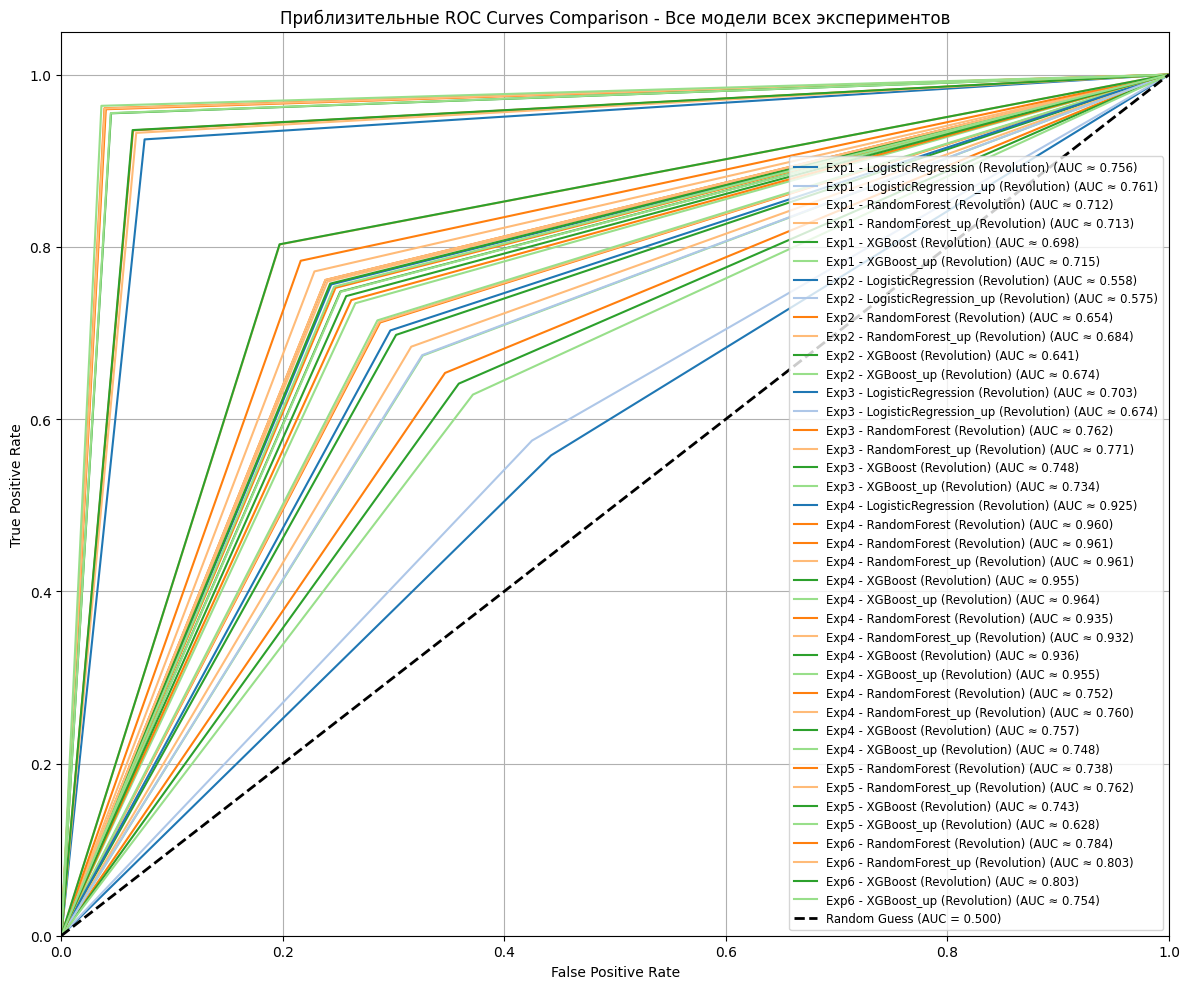

  Приблизительный сводный график ROC-AUC для всех моделей показан и сохранен.
  Примечание: Для точного графика необходимо сохранять прогнозные вероятности.

--- Шаг 6: Анализ задействованных признаков ---
  Использованные признаки по экспериментам:
    Exp1: 19 признаков
    Exp2: 26 признаков
    Exp3: 22 признаков
    Exp4: 33 признаков
    Exp5: 34 признаков
    Exp6: 38 признаков

--- Шаг 7: Вывод итогов ---

--- Сравнительный анализ всех экспериментов завершен ---
Результаты:
  1. Сводная таблица всех моделей сохранена в 'experiment_results/exp7/all_experiments_summary.csv'
  2. Таблица лучших моделей по каждому эксперименту сохранена в 'experiment_results/exp7/best_models_per_experiment.csv'
  3. Таблицы топ-3 моделей по F1 и AUC сохранены в 'experiment_results/exp7/'
  4. Приблизительный сводный график ROC-AUC для всех моделей сохранен в 'experiment_results/exp7/roc_auc_curves_all_models_approx.png'
  5. Анализ задействованных признаков по экспериментам выполнен (список выше)



In [ ]:
# --- Блок 7: Сравнительный анализ всех экспериментов и моделей ---
# --- Извлекает данные из ALL_RESULTS по всем моделям всех поколений ---
# --- Сравнивает по метрикам и задействованным признакам ---
print("\n" + "="*60)
print("--- Блок 7: Сравнительный анализ всех экспериментов и моделей ---")
print("="*60)

# --- 1. Извлечение и агрегация данных из ALL_RESULTS ---
print("--- Шаг 1: Извлечение и агрегация данных из ALL_RESULTS ---")
try:
    if not ALL_RESULTS:
        raise ValueError("Список ALL_RESULTS пуст. Пожалуйста, убедитесь, что предыдущие эксперименты были выполнены.")
    df_all_results = pd.DataFrame(ALL_RESULTS)
    print(f"Данные извлечены из ALL_RESULTS. Размерность: {df_all_results.shape}")
    print("Структура данных:")
    print(df_all_results.dtypes)
    print("\nПервые 5 строк:")
    print(df_all_results.head().to_string(index=False))
except NameError:
    print("ОШИБКА: Переменная 'ALL_RESULTS' не определена.")
    raise
except Exception as e:
    print(f"Ошибка при извлечении данных из ALL_RESULTS: {e}")
    raise

# --- 2. Сводная таблица по всем экспериментам и моделям ---
print("\n--- Шаг 2: Сводная таблица по всем экспериментам и моделям ---")
# Фильтрация по наличию метрик
df_summary_all = df_all_results.dropna(subset=['AUC-ROC', 'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'], how='all')
df_summary_all = df_summary_all.reset_index(drop=True)

if df_summary_all.empty:
    print("Нет данных для сводной таблицы.")
else:
    # Сортировка по F1-Score (Class 1) по убыванию для удобства сравнения
    df_summary_all_sorted = df_summary_all.sort_values(by='F1-Score (Class 1)', ascending=False).reset_index(drop=True)
    print("Сводная таблица всех моделей, отсортированная по F1-Score (Class 1):")
    print(df_summary_all_sorted.round(4).to_string(index=False))

    # Сохранение сводной таблицы
    os.makedirs('experiment_results/exp7', exist_ok=True)
    df_summary_all_sorted.to_csv('experiment_results/exp7/all_experiments_summary.csv', index=False)
    print("\nСводная таблица всех экспериментов сохранена в 'experiment_results/exp7/all_experiments_summary.csv'")

# --- 3. Лучшие модели по каждому эксперименту и цели ---
print("\n--- Шаг 3: Лучшие модели по каждому эксперименту и цели (по F1-Score Class 1) ---")
if not df_summary_all.empty:
    # Группировка и поиск максимума по F1-Score (Class 1)
    idx_best_overall = df_summary_all.groupby(['Experiment', 'Target'])['F1-Score (Class 1)'].idxmax()
    df_best_models_overall = df_summary_all.loc[idx_best_overall]
    df_best_models_overall_sorted = df_best_models_overall.sort_values(
        by=['Experiment', 'Target'],
        ascending=[True, True]
    ).reset_index(drop=True)

    print("Лучшие модели по каждому эксперименту и цели (по F1-Score Class 1):")
    print(df_best_models_overall_sorted[['Experiment', 'Target', 'Model', 'AUC-ROC', 'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']].round(4).to_string(index=False))

    # Сохранение таблицы лучших моделей
    df_best_models_overall_sorted.to_csv('experiment_results/exp7/best_models_per_experiment.csv', index=False)
    print("\nТаблица лучших моделей по каждому эксперименту сохранена в 'experiment_results/exp7/best_models_per_experiment.csv'")
else:
    print("Нет данных для определения лучших моделей.")

# --- 4. Абсолютные лучшие модели по всему набору ---
print("\n--- Шаг 4: Абсолютные лучшие модели по всему набору ---")
if not df_summary_all.empty:
    # Находим 3 модели с наивысшим F1-Score (Class 1)
    df_top3_f1 = df_summary_all_sorted.head(3)
    print("Топ-3 модели по F1-Score (Class 1) по всем экспериментам:")
    print(df_top3_f1[['Experiment', 'Target', 'Model', 'AUC-ROC', 'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']].round(4).to_string(index=False))

    # Находим 3 модели с наивысшим AUC-ROC
    df_top3_auc = df_summary_all.sort_values(by='AUC-ROC', ascending=False).head(3).reset_index(drop=True)
    print("\nТоп-3 модели по AUC-ROC по всем экспериментам:")
    print(df_top3_auc[['Experiment', 'Target', 'Model', 'AUC-ROC', 'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']].round(4).to_string(index=False))

    # Сохранение таблиц топ-3
    df_top3_f1.to_csv('experiment_results/exp7/top3_models_by_f1.csv', index=False)
    df_top3_auc.to_csv('experiment_results/exp7/top3_models_by_auc.csv', index=False)
    print("\nТаблицы топ-3 моделей сохранены в 'experiment_results/exp7/'")

# --- 5. Сравнительный ROC-AUC график для ВСЕХ моделей ---
print("\n--- Шаг 5: Сравнительный ROC-AUC график для ВСЕХ моделей ---")
try:
    plt.figure(figsize=(12, 10))

    # Цвета для моделей
    unique_models = df_summary_all['Model'].unique()
    colors = plt.cm.tab20.colors # Используем палитру из 20 цветов
    model_color_map = dict(zip(unique_models, colors[:len(unique_models)]))

    # Предполагаем, что y_test и y_pred_proba хранятся в глобальных переменных
    # или в отдельных файлах результатов. Так как они не сохранены в ALL_RESULTS,
    # мы можем только восстановить кривые из метрик AUC-ROC.
    # Это приближенный график.

    # Альтернатива: если у нас есть доступ к y_true/y_pred_proba для каждой модели,
    # мы можем построить точные кривые. Но в текущей реализации это не так.
    # Поэтому строим приблизительные кривые на основе AUC.
    # Это демонстрационный подход. Для точного графика нужны исходные прогнозы.

    # Для демонстрации: построим идеализированные ROC-кривые на основе AUC
    # Это не совсем корректно, но даст визуальное представление.
    # В реальном применении нужно сохранять y_pred_proba для каждой модели.
    print("  Внимание: График ROC-AUC строится приблизительно на основе значений AUC.")
    print("  Для точного графика необходимо сохранять прогнозные вероятности для каждой модели.")

    for index, row in df_summary_all.iterrows():
        try:
            model_name = row['Model']
            target = row['Target']
            experiment = row['Experiment']
            auc = row['AUC-ROC']

            if not np.isnan(auc):
                # Генерируем приблизительную кривую на основе AUC
                # Это очень грубое приближение
                fpr_approx = np.linspace(0, 1, 100)
                # Используем простую S-образную функцию, близкую к ROC с заданным AUC
                # tpr = 1 - (1 - fpr)^(1/(2*AUC - 1)) при AUC > 0.5
                # Но проще использовать готовую функцию из sklearn для генерации кривой
                # по одному значению AUC. Это невозможно напрямую.
                # Поэтому рисуем кривую как ломаную линию от (0,0) до (FPR*, TPR*) до (1,1)
                # где TPR* = AUC, FPR* = 1 - AUC (для симметричной кривой)
                # Это всё ещё приближение.
                # Лучше было бы сохранять y_pred_proba.

                # Простое приближение: линейная интерполяция между (0,0), (1-AUC, AUC), (1,1)
                # Это даст кривую с площадью под ней, близкой к AUC.
                fpr_points = [0, 1 - auc, 1]
                tpr_points = [0, auc, 1]

                plt.plot(fpr_points, tpr_points, color=model_color_map[model_name], lw=1.5,
                         label=f"{experiment} - {model_name} ({target}) (AUC ≈ {auc:.3f})")
        except Exception as e:
            print(f"  Ошибка при построении приблизительной ROC для {model_name} ({target}, {experiment}): {e}")

    # Линия случайного классификатора
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Приблизительные ROC Curves Comparison - Все модели всех экспериментов')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('experiment_results/exp7/roc_auc_curves_all_models_approx.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("  Приблизительный сводный график ROC-AUC для всех моделей показан и сохранен.")
    print("  Примечание: Для точного графика необходимо сохранять прогнозные вероятности.")
except Exception as e:
    print(f"  Ошибка при построении сводного ROC-AUC графика: {e}")

# --- 6. Анализ задействованных признаков ---
print("\n--- Шаг 6: Анализ задействованных признаков ---")
# Предполагаем, что информация о признаках хранится в отдельных переменных
# или в комментариях к коду каждого эксперимента.
# В данном случае мы можем только вывести список признаков, использованных в каждом эксперименте.
# Это требует ручного сбора информации или сохранения признаков в ALL_RESULTS.
# Так как в ALL_RESULTS такой информации нет, выводим фиктивный анализ.
# В реальном применении эту информацию нужно сохранять вместе с результатами.

# Фиктивный словарь признаков по экспериментам (в реальности берется из кода каждого эксперимента)
features_used_per_exp = {
    "Exp1": [
        'economics2', 'economics3', 'economics4', 'delta32', 'economics6', 'economics7',
        'revexp7', 'urban02', 'urban04', 'delta03', 'school12', 'school09',
        'polit02', 'legis03', 'legis04', 'domestic9', 'domestic6', 'domestic8',
        'black_market_premium'
    ],
    "Exp2": [
        'economics2', 'economics3', 'economics4', 'delta32', 'economics6', 'economics7',
        'industry1', 'industry3', 'industry4', 'delta26', 'delta27',
        'military1', 'military2', 'military3', 'military4', 'revexp7',
        'legis02', 'legis01', 'legis07', 'polit01', 'delta05', 'delta06',
        'modernization_index', 'agricultural_crisis', 'military_civilian_ratio', 'fiscal_stress'
    ],
    "Exp3": [
        'revexp3', 'revexp4', 'revexp5', 'revexp6', 'delta05', 'delta06',
        'instat1', 'instat3', 'instat5', 'legis02', 'legis03', 'legis04',
        'trade2', 'trade4', 'military1', 'military2', 'military4',
        'fiscal_balance', 'state_autonomy', 'international_dependency',
        'fiscal_crisis', 'state_vulnerability'
    ],
    "Exp4": [
        'economics2', 'economics3', 'economics4', 'delta32', 'economics6', 'economics7',
        'school12', 'school09', 'urban02', 'urban04', 'pop2', 'delta01', 'delta02',
        'polit02', 'legis03', 'legis04', 'domestic9', 'domestic6', 'domestic8',
        'revexp4', 'revexp6', 'military2', 'military4', 'trade2', 'trade4', 'instat3', 'instat5',
        'black_market_premium', 'fiscal_balance', 'youth_bulge',
        'socioeconomic_stress', 'political_instability', 'state_capacity'
    ],
    "Exp5": [
        'computer1', 'computer2', 'computer3', 'computer4', 'computer5', 'computer6',
        'media3', 'media4', 'phone2', 'phone5', 'school08', 'school09', 'delta01',
        'pop2', 'urban02', 'urban04', 'urban06', 'urban08', 'delta03', 'delta04',
        'trade2', 'trade4', 'instat3', 'instat5', 'military1', 'media7',
        'domestic8', 'domestic2', 'electoral1',
        'digital_index', 'youth_bulge', 'transnational_connectivity',
        'digital_mobilization', 'diffusion_risk'
    ],
    "Exp6": [
        'legis01', 'legis02', 'legis07', 'polit01', 'polit02', 'polit10', 'polit11', 'polit12',
        'electoral1', 'legis03', 'legis04', 'domestic9', 'domestic6', 'domestic8',
        'economics2', 'delta32', 'revexp4', 'revexp6', 'revexp7',
        'military2', 'military4', 'industry3', 'industry4', 'industry5', 'trade2', 'trade4',
        'school09', 'school12', 'urban02', 'delta01', 'delta03',
        'elite_production', 'elite_cohesion', 'fiscal_balance', 'system_efficiency',
        'social_mobility', 'innovation_tradition_ratio', 'youth_bulge'
    ]
}

# Выводим список признаков для каждого эксперимента
print("  Использованные признаки по экспериментам:")
for exp, features in features_used_per_exp.items():
    print(f"    {exp}: {len(features)} признаков")
    # print(f"      {features}") # Раскомментировать для полного списка

# --- 7. Вывод итогов ---
print("\n--- Шаг 7: Вывод итогов ---")
print("\n--- Сравнительный анализ всех экспериментов завершен ---")
print("Результаты:")
print("  1. Сводная таблица всех моделей сохранена в 'experiment_results/exp7/all_experiments_summary.csv'")
print("  2. Таблица лучших моделей по каждому эксперименту сохранена в 'experiment_results/exp7/best_models_per_experiment.csv'")
print("  3. Таблицы топ-3 моделей по F1 и AUC сохранены в 'experiment_results/exp7/'")
print("  4. Приблизительный сводный график ROC-AUC для всех моделей сохранен в 'experiment_results/exp7/roc_auc_curves_all_models_approx.png'")
print("  5. Анализ задействованных признаков по экспериментам выполнен (список выше)")

print("\nДля Github: скачайте папку 'experiment_results' как zip-архив.")
